In [1]:
import pandas as pd
import numpy as np
import torch
import os
import random

seed = 42
def set_rnd_seed(seed, deterministic=True, benchmark=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = benchmark and not deterministic
    try:
        torch._dynamo.reset()

    except (AttributeError, RuntimeError):
        pass  # safe to ignore outside PyTorch 2.x

    os.environ["PL_GLOBAL_SEED"] = str(seed)

    print(f"[seed set] {seed}  |  deterministic={deterministic}  benchmark={benchmark}")

set_rnd_seed(seed)

import matplotlib.pyplot as plt
import deeptrack as dt
import deeplay as dl
from torch.utils.data import DataLoader
import scipy
print("NumPy :", np.__version__)   # → 1.26.4
print("Torch :", torch.__version__)   # → 2.2.2
print("SciPy :", scipy.__version__)   # → 1.15.2

from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from single_asset_models.CrossAttentionLSTMV1 import CrossAttentionLSTMV1
from single_asset_models.SimpleGRU import SimpleGRU
from single_asset_models.SimpleLSTM import SimpleLSTM
from train.train_functions import plot_training, test_model_output
from model_inference.inference_functions import test_model_output_percentage_diff
from model_inference.inference_functions import generate_weights_from_predictions

from allocation_functions.allocation_functions import calculate_asset_returns_cont, calculate_portfolio_returns, calculate_cumulative_portfolio_returns
from allocation_functions.allocation_functions import allocate_from_weights, plot_allocations




df = pd.read_csv(
    "data/OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
start_test_point = df.index[-210*22]
print(start_test_point)
all_tickers = df['Ticker'].unique()
print(all_tickers)


feature_cols = ["Close","Volume",
                "MarketCap",
                "Return",
                "SMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"



[seed set] 42  |  deterministic=True  benchmark=False


NumPy : 1.26.4
Torch : 2.2.2
SciPy : 1.15.2
2024-06-27 00:00:00
['ASSA-B.ST' 'ATCO-A.ST' 'ATCO-B.ST' 'AZN.ST' 'ELUX-B.ST' 'ERIC-B.ST'
 'GETI-B.ST' 'HEXA-B.ST' 'HM-B.ST' 'INVE-B.ST' 'KINV-B.ST' 'NDA-SE.ST'
 'NIBE-B.ST' 'SAAB-B.ST' 'SAND.ST' 'SCA-B.ST' 'SEB-A.ST' 'SHB-A.ST'
 'SKF-B.ST' 'SWED-A.ST' 'TEL2-B.ST' 'VOLV-B.ST']


In [2]:

window_step_length = 5
window_size = 100
num_test_points = 511

horizon = 10 #3 is good
target_idx = 0



In [3]:

def generate_loaders_and_benchmark_new_norm(raw_numpy_data, window_step_length, num_test_points, window_size, horizon, target_idx, minimal_plotting=False):

    data = raw_numpy_data[:-num_test_points]
    test_real_data = raw_numpy_data[-num_test_points:]
    #print(data[-1])
    #print(test_real_data[0])
    if not minimal_plotting:
        plt.plot(test_real_data[:,0])
        plt.title('Test data plot')
        plt.show()

    n_samples = data.shape[0]
    past_seq = window_size
    lag = horizon

    in_sequences, targets = [], []
    for i in range(past_seq, n_samples - lag, window_step_length):
        in_sequences.append(data[i - past_seq:i, :])
        targets.append(data[i + lag:i + lag + 1, target_idx])
    in_sequences, targets = np.asarray(in_sequences), np.asarray(targets)
    #print(in_sequences[10][horizon,target_idx])
    #print(targets[9])

    print('in sequences shape: ',in_sequences.shape)
    print('targets shape: ',targets.shape)
    eps = 0
    mean_win = in_sequences.mean(axis=0, keepdims=True)
    std_win = in_sequences.std(axis=0, keepdims=True) + eps

    print(in_sequences[0,0])
    print(mean_win[0,0])
    print(std_win[0,0])
    in_sequences_norm = (in_sequences - mean_win) / std_win
    print(in_sequences_norm[0,0])
    target_mean = mean_win[:,0,target_idx]
    target_std = std_win[:,0,target_idx]
    targets_norm = ((targets.squeeze(-1) - target_mean) / target_std)
    targets_norm = targets_norm.reshape(-1,1)
    print('in sequences norm shape: ',in_sequences_norm.shape)
    print('targets norm shape: ',targets_norm.shape)

    sources = dt.sources.Source(inputs=in_sequences_norm, targets=targets_norm)
    train_sources, val_sources = dt.sources.random_split(sources, [0.8, 0.2])

    inputs_pipeline = dt.Value(sources.inputs) >> dt.pytorch.ToTensor(dtype=torch.float)
    targets_pipeline = dt.Value(sources.targets) >> dt.pytorch.ToTensor(dtype=torch.float) 

    train_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                       inputs=train_sources)
    val_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                     inputs=val_sources)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    print('train loader length: ', len(train_loader))
    print('val loader length: ', len(val_loader))
    #for x, y in train_loader:
    #    print(y[0])
    #    print(x[0])
    target_data = data[:, target_idx]
    indices = np.arange(0, len(target_data)-lag)
    diffs = np.abs(target_data[indices + lag] - target_data[indices])
    benchmark_raw = np.mean(diffs)
    benchmark = 0.1 #benchmark_raw / train_std[target_idx]


    print(f"Benchmark Celsius: {benchmark_raw}")
    print(f"Normalized Benchmark: {benchmark}")

    return train_loader, val_loader, benchmark, mean_win, std_win

In [4]:
def generate_weights_from_predictions_new_norm(model, window_size, real_data, target_idx, num_of_future_predictions, horizon, kelly_clip = 1, print_values_for_allocation=False):
    model.eval()

    # 1) Compute in‐sample return variance (on training history)
    #    use price in column 0
    prices = real_data[:-num_of_future_predictions, 0]
    ret = (prices[horizon:] - prices[:-horizon]) / prices[:-horizon]
    sigma2 = np.var(ret)
    print('variance of returns for old data: ', sigma2)


    last_window = torch.tensor(real_data[-window_size-num_of_future_predictions:-num_of_future_predictions], dtype=torch.float32)
    
    print('start window shape: ',last_window.shape)
    #print(last_window)

    test_real_data_torch = torch.tensor(real_data[-num_of_future_predictions:], dtype=torch.float32)

    #train_mean = real_data.mean(axis=0)
    #train_std = real_data.std(axis=0)
    #train_mean_torch = torch.tensor(train_mean, dtype=torch.float32)
    #train_std_torch = torch.tensor(train_std, dtype=torch.float32)
    #print(train_mean_torch)
    #print(train_std_torch)

    #test_real_data_torch_norm = (test_real_data_torch - train_mean_torch)/ train_std_torch
    print('test data shape', test_real_data_torch.shape)

    #print(test_real_data_torch)

    preds_norm = np.zeros(num_of_future_predictions)
    weights = np.zeros(int(num_of_future_predictions/horizon))
    

    with torch.no_grad():
        for t in range(int(num_of_future_predictions/horizon)-1):

            idx_start = t * horizon
            idx_end = idx_start + horizon
            lw_mean = last_window.mean(axis=0, keepdim=True)
            lw_std = last_window.std(axis=0, keepdim=True)
            #lw_mean_t = torch.tensor(lw_mean)
            #lw_std_t = torch.tensor(lw_std)
            print('lw mean', lw_mean)

            last_window_norm = (last_window - lw_mean ) / lw_std

            x_in  = last_window_norm.unsqueeze(0)
            pred_torch = model(x_in)
            #print('pred:', pred_torch)
            pred_norm = pred_torch.squeeze().item()

            preds_norm[idx_start] = pred_norm
            #print('real: ', test_real_data_torch[t, 0])

            last_price_real = test_real_data_torch[idx_start, 0] if t>0 else real_data[-num_of_future_predictions-1, 0]
            #print(last_price_real)
            pred_price = pred_norm * lw_std[0,target_idx] + lw_mean[0,target_idx]
            pred_ret = (pred_price - last_price_real)/last_price_real
            print('ret shape', pred_ret.shape)

            #kelly weight
            k = pred_ret / np.sqrt(sigma2) if sigma2 > 1e-8 else 0.0
            k = np.clip(k, -kelly_clip, kelly_clip)
            #print(k.shape)

            weights[t] = k
            
            true_horizon_price = test_real_data_torch[idx_end, 0]
            if print_values_for_allocation:
                print('x_in shape: ', x_in.shape)
                print('windows last price: ',x_in[0,-1,0] * lw_std[0,target_idx] + lw_mean[0,target_idx])
                print('windows last2 price: ',x_in[0,-2,0] * lw_std[0,target_idx] + lw_mean[0,target_idx])
                print('windows last3 price: ',x_in[0,-3,0] * lw_std[0,target_idx] + lw_mean[0,target_idx])

                print(f'period from idx: ', idx_start, ' to idx ', idx_end)
                
                print(f'prediction at {horizon}: ', pred_price)
                print('last price from test data: ', last_price_real)
                print(f'real price {horizon} steps forward: ', true_horizon_price)
                print(f'kelly weight: ', {k})
                print(' ')
            
            

            true_row = test_real_data_torch[idx_end, :]# if t>0 else real_data[-num_of_future_predictions-1, 0]
            #true_indicators[0] = pred_norm

            next_data_point = torch.tensor(true_row, dtype=torch.float32)
            if horizon > 1:
                middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)
                #print(middle_points.shape)
                #print(next_data_point.unsqueeze(0).shape)
                #print('last window in: ',last_window.shape)
                modified_next_data_point = torch.cat([middle_points, next_data_point.unsqueeze(0)], dim=0)
            else:
                modified_next_data_point = next_data_point.unsqueeze(0)
            #print('mod shape', modified_next_data_point.shape)
            last_window = torch.cat([last_window[horizon:], modified_next_data_point], dim=0)
            #print('last window shape: ', last_window.shape)

    return preds_norm, weights

In [5]:
def generate_test_data_loader(data):
    in_seqs, targets, mu_list, sigma_list = [], [], [], []
    n_samples = data.shape[0]
    past_seq = window_size
    lag = horizon

    for i in range(past_seq, n_samples - lag, window_step_length):
        win   = data[i - past_seq : i, :]           # (past_seq, F)
        μ     = win.mean(axis=0)                    # (F,)
        σ     = win.std(axis=0) + 1e-8              # (F,)
    
        in_seqs.append((win - μ) / σ)               # normalised
        targets.append(data[i + lag, target_idx])   # scalar
        mu_list.append(μ[target_idx])
        sigma_list.append(σ[target_idx])
    
    in_seqs = np.asarray(in_seqs)                   # (N, past_seq, F)
    targets = np.asarray(targets).reshape(-1, 1)    # (N, 1)
    mu_arr  = np.asarray(mu_list).reshape(-1, 1)    # (N, 1)
    sigma_arr = np.asarray(sigma_list).reshape(-1, 1)
    
    targets_norm = (targets - mu_arr) / sigma_arr   # (N, 1)
    
    # ------------------------------------------------------------------
    # Build dt Source with μ and σ columns
    # ------------------------------------------------------------------
    test_sources = dt.sources.Source(
        inputs=in_seqs,
        targets=targets_norm,
        mu=mu_arr,
        sigma=sigma_arr,
    )
    
    
    # ------------------------------------------------------------------
    # Pipelines  →  tensors
    # ------------------------------------------------------------------
    to_tensor = dt.pytorch.ToTensor(dtype=torch.float)
    
    inp_pipe  = dt.Value(test_sources.inputs) >> to_tensor
    tgt_pipe  = dt.Value(test_sources.targets) >> to_tensor
    mu_pipe   = dt.Value(test_sources.mu)      >> to_tensor
    sigma_pipe= dt.Value(test_sources.sigma)   >> to_tensor
    
    dataset_cols = inp_pipe & tgt_pipe & mu_pipe & sigma_pipe
    
    test_ds = dt.pytorch.Dataset(dataset_cols, inputs=test_sources)
    
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    return test_loader
   

In [6]:
def test_model_output_percentage_diff_new_norm(model, data_loader, tm, tstd, target_idx, num_tests=20):
    
    model.eval()

    all_preds_real, all_true_real = [], []
    first_batch = None   # keep for pretty print

    with torch.no_grad():
        for x_batch, y_norm, mu_batch, sigma_batch in data_loader:
            # to(device) only if you trained on GPU
            #x_batch     = x_batch.to(device)
            #y_norm      = y_norm.to(device)
            #mu_batch    = mu_batch.to(device)
            #sigma_batch = sigma_batch.to(device)

            # forward
            out = model(x_batch)
            if isinstance(out, (tuple, list)):   # ignore extra returns
                out = out[0]
            out = out.squeeze(-1)                # (B,)

            # ------------------------------------------
            # de-normalise: y_real = y_norm * σ + μ
            # ------------------------------------------
            preds_real = out * sigma_batch.squeeze(-1) + mu_batch.squeeze(-1)
            true_real  = y_norm.squeeze(-1) * sigma_batch.squeeze(-1) + mu_batch.squeeze(-1)

            all_preds_real.append(preds_real)
            all_true_real.append(true_real)

            if first_batch is None:
                first_batch = (
                    x_batch.cpu(),      # still normalised
                    y_norm.cpu(),
                    mu_batch.cpu(),
                    sigma_batch.cpu(),
                    out.cpu(),          # preds in norm space
                )

    # ------------------------------------------------------------------
    # 1. MAPE over the whole loader   (real price space)
    # ------------------------------------------------------------------
    preds = torch.cat(all_preds_real)            # (N,)
    truth = torch.cat(all_true_real)             # (N,)

    mape = ((preds - truth).abs() / truth.abs().clamp(min=1e-8) * 100).mean().item()
    print(f"\nMean absolute percentage error (MAPE): {mape:.2f}%")

    # ------------------------------------------------------------------
    # 2. Pretty-print a few samples from the first batch
    # ------------------------------------------------------------------
    x_b, y_norm_b, mu_b, sigma_b, p_norm_b = first_batch
    num_tests = min(num_tests, x_b.size(0))

    print(f"\nFirst-batch sample comparisons (n = {num_tests}):")
    for i in range(num_tests):
        # last raw price of target feature in the window
        last_price = (
            x_b[i, -1, target_idx].item() * sigma_b[i].item() + mu_b[i].item()
        )

        true_price = y_norm_b[i].item() * sigma_b[i].item() + mu_b[i].item()
        pred_price = p_norm_b[i].item()  * sigma_b[i].item() + mu_b[i].item()
        pct = abs(pred_price - true_price) / abs(true_price) * 100

        print(
            f"  Sample {i+1:2d}: "
            f"Last input price = {last_price:9.4f}, "
            f"True = {true_price:9.4f}, "
            f"Pred = {pred_price:9.4f}, "
            f"Pct diff = {pct:6.2f}%"
        )

    return mape

Shape dataset (6409, 7)
means:  Close           1.043935e+02
Volume          4.174720e+06
MarketCap       1.099524e+11
Return          5.710548e-04
SMA20           1.040219e+02
RSI14           5.227815e+01
ReturnVola20    1.814528e-02
dtype: float64
stds:  Close           8.875950e+01
Volume          4.600011e+06
MarketCap       9.348594e+10
Return          2.000137e-02
SMA20           8.849015e+01
RSI14           1.056618e+01
ReturnVola20    8.856161e-03
dtype: float64


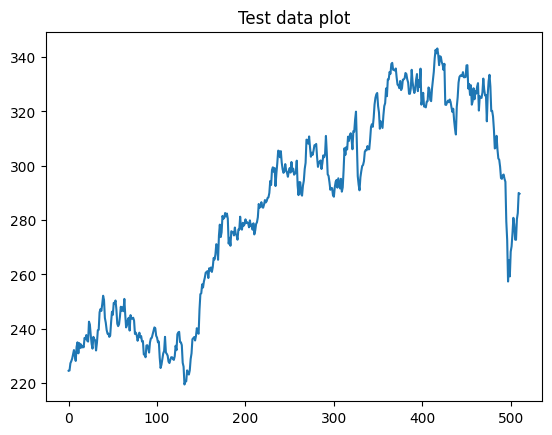

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[2.68834782e+01 1.57131000e+05 2.83150229e+10 3.92147114e-03
 2.63111549e+01 5.31894275e+01 2.79775678e-02]
[8.60464188e+01 4.18998783e+06 9.06283892e+10 2.48347922e-05
 8.57516136e+01 5.21293195e+01 1.87274738e-02]
[7.14054715e+01 4.61965502e+06 7.52078117e+10 2.03960275e-02
 7.11762501e+01 1.04894220e+01 9.06993074e-03]
[-0.82854912 -0.87297792 -0.82854912  0.19104879 -0.83511647  0.10106448
  1.01986379]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 3.2277497066103895
Normalized Benchmark: 0.1


/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ train │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

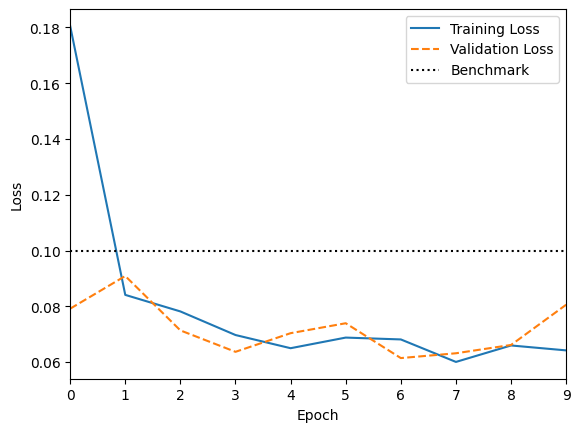

variance of returns for old data:  0.0030524899772000364
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[ 2.3280e+02,  1.5429e+06,  2.4519e+11, -4.0584e-05,  2.3219e+02,
          5.3264e+01,  1.5790e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(223.0063)
windows last2 price:  tensor(223.8647)
windows last3 price:  tensor(224.2462)
period from idx:  0  to idx  10
prediction at 10:  tensor(232.0281)
last price from test data:  223.0062561035156
real price 10 steps forward:  tensor(234.9978)
kelly weight:  {tensor(0.7322, dtype=torch.float64)}
 
lw mean tensor([[2.3279e+02, 1.6133e+06, 2.4518e+11, 2.4299e-04, 2.3276e+02, 5.1873e+01,
         1.5544e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(234.9978)
windows last2 price:  tensor(233.3598)
windows last3 price:  tensor(228.1569)
period from idx:  10  to idx  20
prediction at 10:  tensor(23

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(226.0372)
windows last2 price:  tensor(227.4825)
windows last3 price:  tensor(233.9380)
period from idx:  130  to idx  140
prediction at 10:  tensor(238.0670)
last price from test data:  tensor(226.0372)
real price 10 steps forward:  tensor(236.1540)
kelly weight:  {tensor(0.9633, dtype=torch.float64)}
 
lw mean tensor([[ 2.3616e+02,  1.5037e+06,  2.4874e+11, -5.2248e-04,  2.3761e+02,
          4.7208e+01,  1.1860e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(236.1540)
windows last2 price:  tensor(230.9511)
windows last3 price:  tensor(228.8314)
period from idx:  140  to idx  150
prediction at 10:  tensor(236.3997)
last price from test data:  tensor(236.1540)
real price 10 steps forward:  tensor(253.0426)
kelly weight:  {tensor(0.0188, dtype=torch.float64)}
 
lw mean tensor([[2.3622e+02, 1.4847e+06, 2.4880e+11, 3.9241e-04, 2.3655e+02, 4.8667e+01,


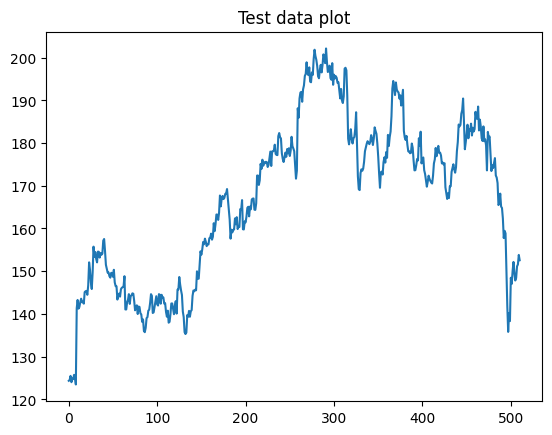

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 3.57618880e+00  3.04256470e+07  1.18267779e+10 -4.30106086e-02
  3.98403440e+00  2.49887626e+01  2.47445707e-02]
[3.12838688e+01 4.00236684e+07 1.03458567e+11 5.94237762e-04
 3.10993355e+01 5.29894757e+01 1.97462351e-02]
[3.37525211e+01 6.01907202e+07 1.11622622e+11 2.14643112e-02
 3.35317234e+01 1.12496507e+01 8.92736817e-03]
[-0.82090697 -0.15946015 -0.82090697 -2.03150457 -0.80864621 -2.48902956
  0.55988904]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 1.391148327242421
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

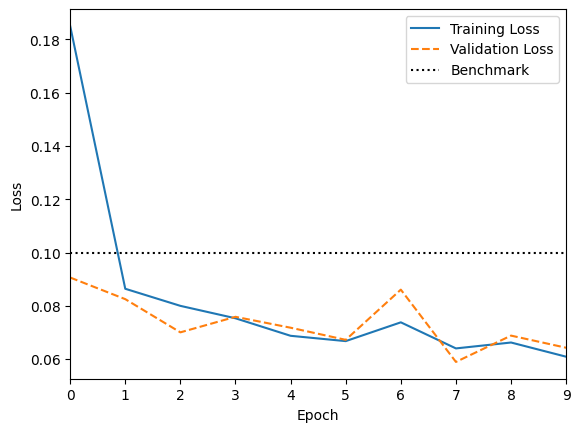

variance of returns for old data:  0.003603986967925918
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.2237e+02, 4.3059e+06, 4.0469e+11, 1.6574e-05, 1.2234e+02, 5.1374e+01,
         1.8798e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(122.3797)
windows last2 price:  tensor(122.7636)
windows last3 price:  tensor(123.3396)
period from idx:  0  to idx  10
prediction at 10:  tensor(122.2421)
last price from test data:  122.37970733642578
real price 10 steps forward:  tensor(143.2714)
kelly weight:  {tensor(-0.0187, dtype=torch.float64)}
 
lw mean tensor([[1.2267e+02, 4.4546e+06, 4.0569e+11, 1.3112e-03, 1.2245e+02, 5.0937e+01,
         1.8831e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(143.2714)
windows last2 price:  tensor(141.3366)
windows last3 price:  tensor(123.4835)
period from idx:  10  to idx  20
prediction at 10:  tensor(123.8564

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(139.2462)
windows last2 price:  tensor(140.5627)
windows last3 price:  tensor(144.4322)
period from idx:  130  to idx  140
prediction at 10:  tensor(144.3225)
last price from test data:  tensor(139.2462)
real price 10 steps forward:  tensor(144.2193)
kelly weight:  {tensor(0.6073, dtype=torch.float64)}
 
lw mean tensor([[ 1.4301e+02,  3.9273e+06,  4.7295e+11, -7.9430e-04,  1.4429e+02,
          4.7024e+01,  1.3113e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(144.2193)
windows last2 price:  tensor(140.9039)
windows last3 price:  tensor(140.6114)
period from idx:  140  to idx  150
prediction at 10:  tensor(142.7923)
last price from test data:  tensor(144.2193)
real price 10 steps forward:  tensor(153.8730)
kelly weight:  {tensor(-0.1648, dtype=torch.float64)}
 
lw mean tensor([[1.4288e+02, 3.8946e+06, 4.7253e+11, 4.3731e-04, 1.4324e+02, 4.8314e+01,

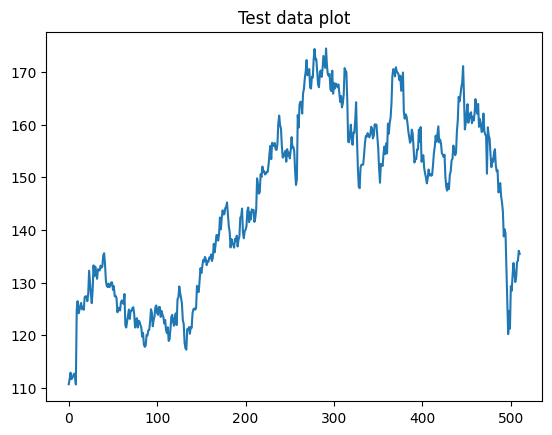

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 2.76596975e+00  8.51722400e+06  4.31734687e+09 -5.89518352e-02
  3.11219729e+00  2.64108343e+01  2.97870997e-02]
[2.70144321e+01 6.30582592e+06 4.21662868e+10 5.03845187e-04
 2.68478840e+01 5.29263575e+01 2.06001088e-02]
[2.93340754e+01 5.44143848e+06 4.57869716e+10 2.24101641e-02
 2.91288482e+01 1.08131807e+01 9.23072356e-03]
[-0.82663121  0.40639954 -0.82663121 -2.65306761 -0.81485154 -2.45214836
  0.99526227]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 1.2199749268753373
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

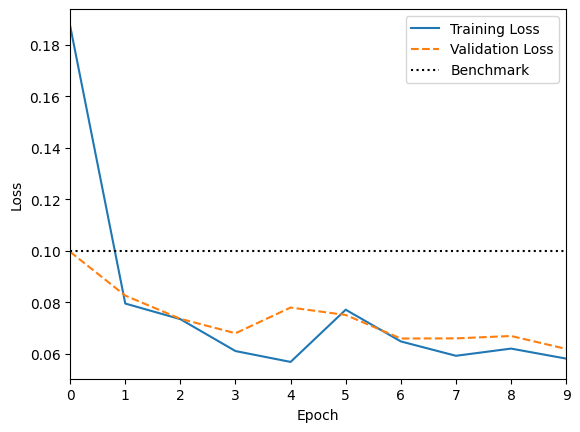

variance of returns for old data:  0.0038015205070000683
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[ 1.0883e+02,  1.9445e+06,  1.6988e+11, -5.6051e-05,  1.0876e+02,
          5.1611e+01,  1.8203e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(109.0790)
windows last2 price:  tensor(110.4156)
windows last3 price:  tensor(111.2272)
period from idx:  0  to idx  10
prediction at 10:  tensor(109.1199)
last price from test data:  109.07901763916016
real price 10 steps forward:  tensor(126.4697)
kelly weight:  {tensor(0.0061, dtype=torch.float64)}
 
lw mean tensor([[1.0907e+02, 2.0135e+06, 1.7025e+11, 1.1787e-03, 1.0889e+02, 5.1002e+01,
         1.8488e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(126.4697)
windows last2 price:  tensor(124.8322)
windows last3 price:  tensor(110.6543)
period from idx:  10  to idx  20
prediction at 10:  tensor(1

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(124.2184)
windows last2 price:  tensor(121.3997)
windows last3 price:  tensor(121.5455)
period from idx:  140  to idx  150
prediction at 10:  tensor(123.8619)
last price from test data:  tensor(124.2184)
real price 10 steps forward:  tensor(131.7998)
kelly weight:  {tensor(-0.0466, dtype=torch.float64)}
 
lw mean tensor([[1.2368e+02, 1.4762e+06, 1.9305e+11, 3.3542e-04, 1.2404e+02, 4.8117e+01,
         1.2838e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(131.7998)
windows last2 price:  tensor(132.7232)
windows last3 price:  tensor(130.5849)
period from idx:  150  to idx  160
prediction at 10:  tensor(124.9718)
last price from test data:  tensor(131.7998)
real price 10 steps forward:  tensor(134.5699)
kelly weight:  {tensor(-0.8402, dtype=torch.float64)}
 
lw mean tensor([[1.2445e+02, 1.6054e+06, 1.9426e+11, 6.9522e-04, 1.2387e+02, 5.0782e+01,
     

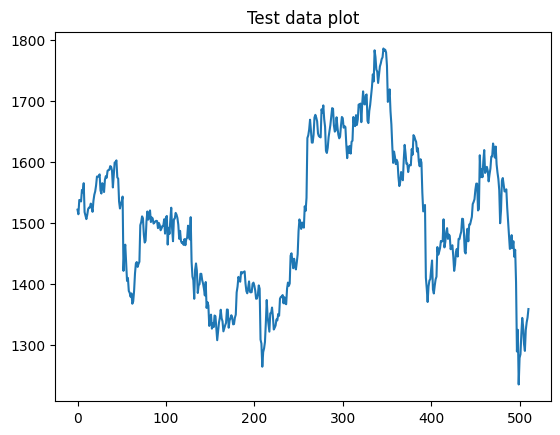

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 2.70022095e+02  1.27078000e+06  4.18588269e+11 -6.10652330e-03
  2.79458354e+02  3.75416964e+01  1.74502300e-02]
[4.63074254e+02 1.06400699e+06 7.17857738e+11 6.63166763e-05
 4.61529498e+02 5.16000610e+01 1.47630778e-02]
[2.61261723e+02 9.30226197e+05 4.05007940e+11 1.71344748e-02
 2.59008231e+02 1.22695230e+01 6.62779517e-03]
[-0.73892247  0.22228251 -0.73892247 -0.36025849 -0.70295505 -1.14579552
  0.40543682]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 17.46821867642195
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

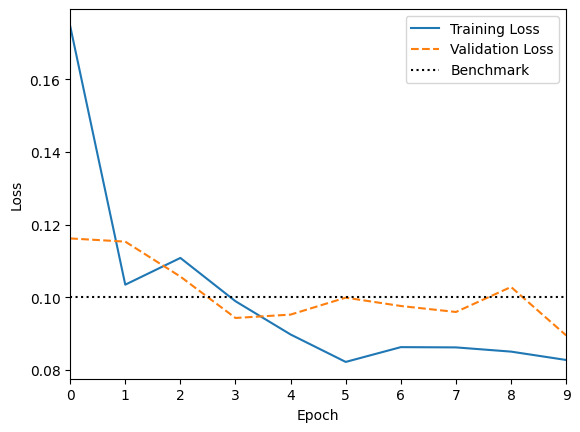

variance of returns for old data:  0.002340452120322088
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.4103e+03, 3.5468e+05, 2.1862e+12, 1.1357e-03, 1.3979e+03, 5.5715e+01,
         1.2647e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(1528.6642)
windows last2 price:  tensor(1518.1973)
windows last3 price:  tensor(1506.7335)
period from idx:  0  to idx  10
prediction at 10:  tensor(1424.0844)
last price from test data:  1528.6641845703125
real price 10 steps forward:  tensor(1506.2351)
kelly weight:  {tensor(-1.4141, dtype=torch.float64)}
 
lw mean tensor([[1.4240e+03, 3.5203e+05, 2.2074e+12, 7.0951e-04, 1.4114e+03, 5.6089e+01,
         1.1728e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(1506.2351)
windows last2 price:  tensor(1511.7178)
windows last3 price:  tensor(1517.6990)
period from idx:  10  to idx  20
prediction at 10:  tensor(

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(1416.6882)
windows last2 price:  tensor(1416.6882)
windows last3 price:  tensor(1399.7339)
period from idx:  140  to idx  150
prediction at 10:  tensor(1476.9316)
last price from test data:  tensor(1416.6882)
real price 10 steps forward:  tensor(1345.8788)
kelly weight:  {tensor(0.8790, dtype=torch.float64)}
 
lw mean tensor([[ 1.4571e+03,  2.8796e+05,  2.2587e+12, -1.1929e-03,  1.4746e+03,
          4.5826e+01,  1.4894e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(1345.8788)
windows last2 price:  tensor(1331.4177)
windows last3 price:  tensor(1364.8278)
period from idx:  150  to idx  160
prediction at 10:  tensor(1457.2189)
last price from test data:  tensor(1345.8788)
real price 10 steps forward:  tensor(1336.9030)
kelly weight:  {tensor(1.7100, dtype=torch.float64)}
 
lw mean tensor([[ 1.4475e+03,  2.8884e+05,  2.2440e+12, -2.2004e-04,  1.4582e

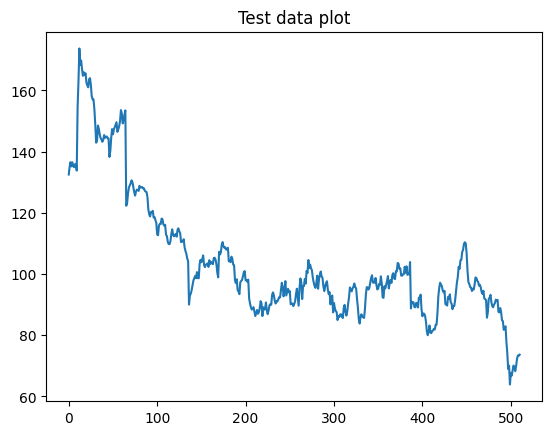

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 2.73251572e+01  1.65003200e+06  7.16752513e+09 -5.06330515e-02
  3.01378270e+01  2.75933695e+01  2.55974566e-02]
[8.29465119e+01 2.61032838e+06 2.17572841e+10 6.21434310e-04
 8.27883336e+01 5.13004188e+01 2.05428639e-02]
[5.22340789e+01 1.78807788e+06 1.37012596e+10 2.12950895e-02
 5.21638919e+01 1.18888243e+01 9.17637068e-03]
[-1.06484801 -0.53705512 -1.06484801 -2.40686876 -1.00932857 -1.99406171
  0.550827  ]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 3.834082154152186
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

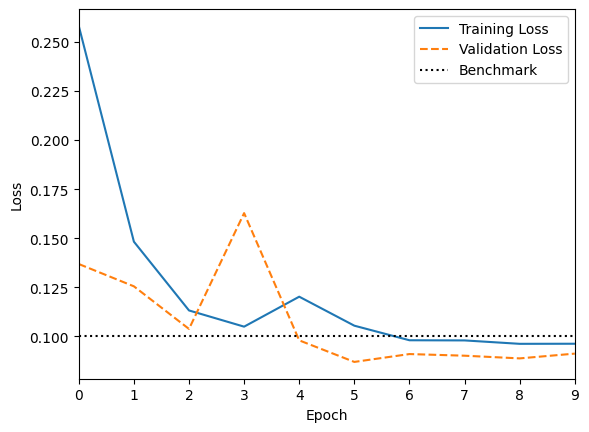

variance of returns for old data:  0.004363216822222553
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[ 1.3713e+02,  1.7312e+06,  3.5969e+10, -8.5121e-04,  1.3888e+02,
          4.5880e+01,  2.0461e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(127.7000)
windows last2 price:  tensor(126.3000)
windows last3 price:  tensor(127.1500)
period from idx:  0  to idx  10
prediction at 10:  tensor(135.5465)
last price from test data:  127.6999969482422
real price 10 steps forward:  tensor(154.5500)
kelly weight:  {tensor(0.9302, dtype=torch.float64)}
 
lw mean tensor([[1.3638e+02, 1.8313e+06, 3.5773e+10, 8.8424e-05, 1.3745e+02, 4.6512e+01,
         1.9970e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(154.5500)
windows last2 price:  tensor(133.8000)
windows last3 price:  tensor(136.)
period from idx:  10  to idx  20
prediction at 10:  tensor(137.602

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(96.2400)
windows last2 price:  tensor(94.7200)
windows last3 price:  tensor(93.6000)
period from idx:  140  to idx  150
prediction at 10:  tensor(121.0800)
last price from test data:  tensor(96.2400)
real price 10 steps forward:  tensor(103.8500)
kelly weight:  {tensor(3.9074, dtype=torch.float64)}
 
lw mean tensor([[ 1.1991e+02,  1.3099e+06,  3.1453e+10, -2.9514e-03,  1.2412e+02,
          3.7309e+01,  2.3072e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(103.8500)
windows last2 price:  tensor(104.6000)
windows last3 price:  tensor(103.2500)
period from idx:  150  to idx  160
prediction at 10:  tensor(117.8340)
last price from test data:  tensor(103.8500)
real price 10 steps forward:  tensor(103.2500)
kelly weight:  {tensor(2.0385, dtype=torch.float64)}
 
lw mean tensor([[ 1.1536e+02,  1.3434e+06,  3.0258e+10, -3.4633e-03,  1.1964e+02,
          3

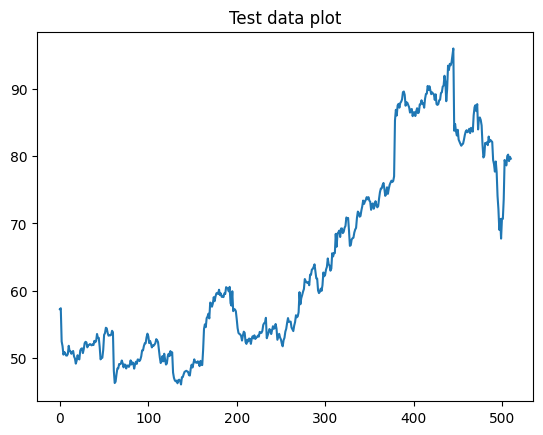

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 3.12475800e+02  5.59376930e+07  9.59588162e+11 -9.53905175e-03
  2.81729825e+02  6.76608207e+01  3.46125789e-02]
[ 7.30919883e+01  1.66158408e+07  2.24459644e+11 -7.85399521e-04
  7.34599317e+01  5.03481710e+01  2.36625769e-02]
[6.28214301e+01 1.51339154e+07 1.92919582e+11 2.87918599e-02
 6.29218448e+01 1.21672274e+01 1.41646311e-02]
[ 3.8105438   2.59826034  3.8105438  -0.30403219  3.30997754  1.42289193
  0.77305239]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 4.446337926322999
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

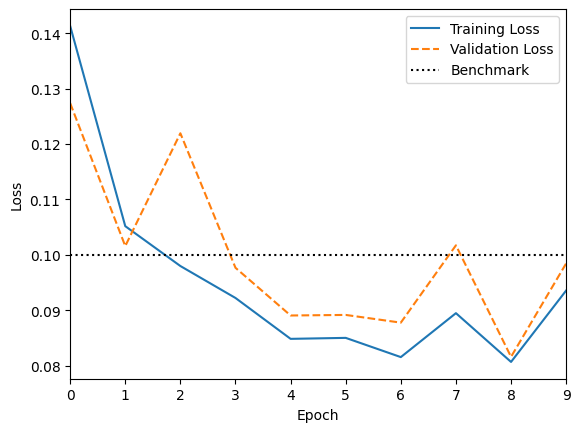

variance of returns for old data:  0.0072873142343836995
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[ 5.5228e+01,  9.1189e+06,  1.6960e+11, -1.6557e-04,  5.5378e+01,
          4.7875e+01,  1.7856e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(56.3482)
windows last2 price:  tensor(56.0999)
windows last3 price:  tensor(56.7160)
period from idx:  0  to idx  10
prediction at 10:  tensor(54.8185)
last price from test data:  56.34817123413086
real price 10 steps forward:  tensor(51.8333)
kelly weight:  {tensor(-0.3180, dtype=torch.float64)}
 
lw mean tensor([[ 5.4523e+01,  1.0073e+07,  1.6743e+11, -1.6335e-03,  5.5121e+01,
          4.6491e+01,  1.9244e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(51.8333)
windows last2 price:  tensor(50.6288)
windows last3 price:  tensor(50.3805)
period from idx:  10  to idx  20
prediction at 10:  tensor(53

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(47.6075)
windows last2 price:  tensor(47.1924)
windows last3 price:  tensor(47.1735)
period from idx:  140  to idx  150
prediction at 10:  tensor(49.5132)
last price from test data:  tensor(47.6075)
real price 10 steps forward:  tensor(48.6073)
kelly weight:  {tensor(0.4689, dtype=torch.float64)}
 
lw mean tensor([[ 4.9887e+01,  6.9771e+06,  1.5320e+11, -8.0754e-04,  5.0263e+01,
          4.8195e+01,  1.6258e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(48.6073)
windows last2 price:  tensor(49.0318)
windows last3 price:  tensor(48.4658)
period from idx:  150  to idx  160
prediction at 10:  tensor(49.2556)
last price from test data:  tensor(48.6073)
real price 10 steps forward:  tensor(49.0129)
kelly weight:  {tensor(0.1562, dtype=torch.float64)}
 
lw mean tensor([[ 4.9442e+01,  7.1782e+06,  1.5183e+11, -7.9651e-04,  4.9837e+01,
          4.7946e+0

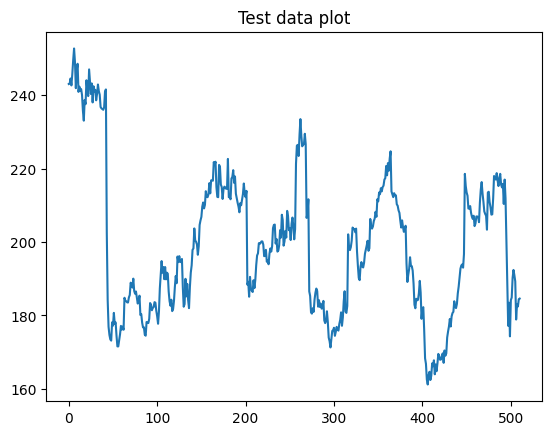

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 9.10091019e+00  2.01714500e+06  2.31301453e+09 -9.99990767e-03
  9.08712144e+00  5.18001043e+01  1.60951852e-02]
[9.15943243e+01 1.06041489e+06 2.32788807e+10 7.19398755e-04
 9.12260223e+01 5.26954974e+01 1.84075835e-02]
[7.05310951e+01 9.21038498e+05 1.79256189e+10 2.05393560e-02
 7.01181594e+01 1.19954685e+01 7.80334187e-03]
[-1.16960348  1.03875148 -1.16960348 -0.52189107 -1.1714355  -0.07464428
 -0.29633436]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 4.420217819349921
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

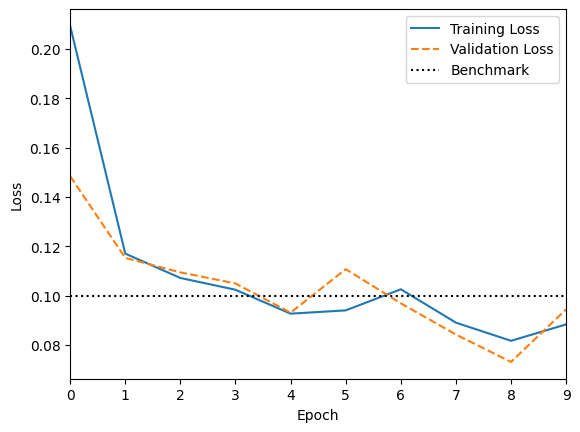

variance of returns for old data:  0.003646607336888028
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[2.1889e+02, 7.8792e+05, 5.5632e+10, 1.1849e-03, 2.1759e+02, 5.2557e+01,
         2.1859e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(243.8951)
windows last2 price:  tensor(242.1080)
windows last3 price:  tensor(243.2367)
period from idx:  0  to idx  10
prediction at 10:  tensor(233.9119)
last price from test data:  243.89505004882807
real price 10 steps forward:  tensor(248.5668)
kelly weight:  {tensor(-0.6778, dtype=torch.float64)}
 
lw mean tensor([[2.2138e+02, 8.0157e+05, 5.6264e+10, 7.9990e-04, 2.1940e+02, 5.3513e+01,
         2.1141e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(248.5668)
windows last2 price:  tensor(246.8453)
windows last3 price:  tensor(241.9198)
period from idx:  10  to idx  20
prediction at 10:  tensor(249.0347

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(182.3843)
windows last2 price:  tensor(187.6923)
windows last3 price:  tensor(195.3913)
period from idx:  130  to idx  140
prediction at 10:  tensor(190.8111)
last price from test data:  tensor(182.3843)
real price 10 steps forward:  tensor(197.8779)
kelly weight:  {tensor(0.7651, dtype=torch.float64)}
 
lw mean tensor([[ 1.8519e+02,  8.5865e+05,  4.7066e+10, -1.4718e-03,  1.8988e+02,
          4.3970e+01,  2.0528e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(197.8779)
windows last2 price:  tensor(193.6698)
windows last3 price:  tensor(191.6613)
period from idx:  140  to idx  150
prediction at 10:  tensor(186.7756)
last price from test data:  tensor(197.8779)
real price 10 steps forward:  tensor(206.8680)
kelly weight:  {tensor(-0.9291, dtype=torch.float64)}
 
lw mean tensor([[1.8610e+02, 7.5081e+05, 4.7298e+10, 1.6731e-03, 1.8617e+02, 4.7580e+01,

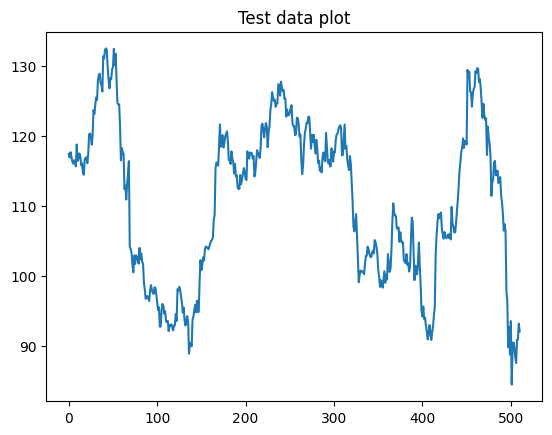

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 1.14148211e+00  9.72000000e+05  2.93832326e+09 -8.00099289e-03
  1.18267759e+00  3.25515117e+01  1.63444294e-02]
[ 3.22444630e+01  5.18832849e+06  8.30014370e+10 -3.11490347e-04
  3.20767587e+01  5.37059713e+01  2.00602666e-02]
[3.59489320e+01 6.78198154e+06 9.25372214e+10 2.24161174e-02
 3.57852232e+01 1.21452035e+01 1.00301911e-02]
[-0.86519903 -0.62169566 -0.86519903 -0.34303454 -0.8633195  -1.7417954
 -0.37046524]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 1.4678080804727
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

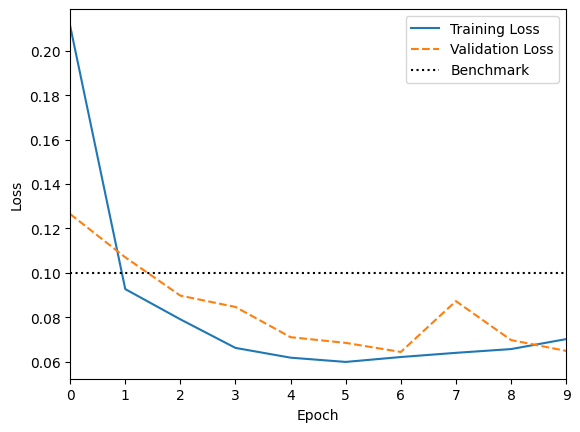

variance of returns for old data:  0.004510445296041606
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[ 1.1659e+02,  3.1407e+06,  3.0013e+11, -2.5575e-04,  1.1666e+02,
          5.0232e+01,  1.6578e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(116.3312)
windows last2 price:  tensor(116.4807)
windows last3 price:  tensor(117.7760)
period from idx:  0  to idx  10
prediction at 10:  tensor(116.8690)
last price from test data:  116.33123016357422
real price 10 steps forward:  tensor(116.4309)
kelly weight:  {tensor(0.0688, dtype=torch.float64)}
 
lw mean tensor([[ 1.1626e+02,  3.2758e+06,  2.9926e+11, -2.9396e-04,  1.1660e+02,
          4.9445e+01,  1.5072e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(116.4309)
windows last2 price:  tensor(118.7724)
windows last3 price:  tensor(115.6337)
period from idx:  10  to idx  20
prediction at 10:  te

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(93.7588)
windows last2 price:  tensor(90.0085)
windows last3 price:  tensor(90.4673)
period from idx:  140  to idx  150
prediction at 10:  tensor(104.5752)
last price from test data:  tensor(93.7588)
real price 10 steps forward:  tensor(100.8406)
kelly weight:  {tensor(1.7178, dtype=torch.float64)}
 
lw mean tensor([[ 1.0101e+02,  4.9451e+06,  2.6003e+11, -2.3323e-03,  1.0418e+02,
          3.9526e+01,  1.7324e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(100.8406)
windows last2 price:  tensor(102.2869)
windows last3 price:  tensor(99.4243)
period from idx:  150  to idx  160
prediction at 10:  tensor(101.5739)
last price from test data:  tensor(100.8406)
real price 10 steps forward:  tensor(104.6309)
kelly weight:  {tensor(0.1083, dtype=torch.float64)}
 
lw mean tensor([[ 9.8850e+01,  4.7340e+06,  2.5445e+11, -1.0517e-03,  1.0103e+02,
          4.

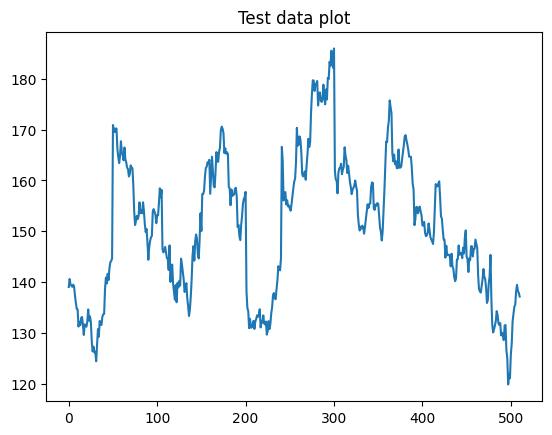

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 5.56863670e+01  9.39295200e+06  7.85227884e+10 -5.26313638e-02
  6.30287111e+01  3.22534727e+01  3.88828957e-02]
[1.09046333e+02 4.47743031e+06 1.53765142e+11 3.29560951e-04
 1.09005849e+02 5.12129535e+01 1.77085723e-02]
[5.23950457e+01 3.00588106e+06 7.38817291e+10 1.97682226e-02
 5.23403934e+01 1.17847135e+01 9.23195385e-03]
[-1.01841625  1.63530146 -1.01841625 -2.6790939  -0.87842554 -1.60881982
  2.29359069]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 4.38901626351087
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

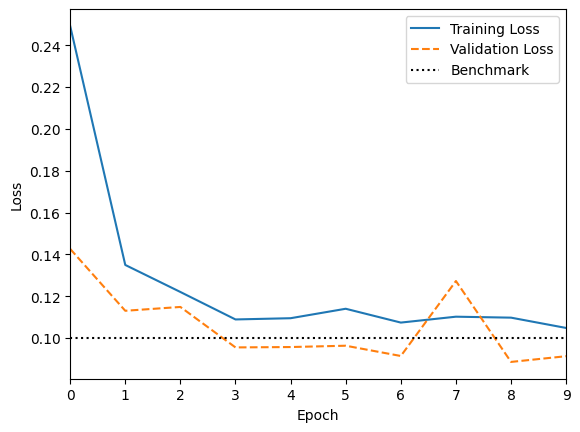

variance of returns for old data:  0.0034764847310233115
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.1375e+02, 3.6945e+06, 1.6040e+11, 2.9260e-03, 1.1164e+02, 5.4794e+01,
         2.4609e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(136.7445)
windows last2 price:  tensor(135.0379)
windows last3 price:  tensor(136.4571)
period from idx:  0  to idx  10
prediction at 10:  tensor(117.3009)
last price from test data:  136.74452209472656
real price 10 steps forward:  tensor(134.6247)
kelly weight:  {tensor(-2.4116, dtype=torch.float64)}
 
lw mean tensor([[1.1696e+02, 3.6267e+06, 1.6493e+11, 2.3469e-03, 1.1419e+02, 5.6025e+01,
         2.5959e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(134.6247)
windows last2 price:  tensor(134.7325)
windows last3 price:  tensor(135.9541)
period from idx:  10  to idx  20
prediction at 10:  tensor(119.566

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


tensor(145.7645)
real price 10 steps forward:  tensor(136.5417)
kelly weight:  {tensor(0.0630, dtype=torch.float64)}
 
lw mean tensor([[1.4876e+02, 2.8173e+06, 2.0977e+11, 6.7677e-04, 1.4778e+02, 5.2736e+01,
         2.0343e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(136.5417)
windows last2 price:  tensor(138.1584)
windows last3 price:  tensor(139.6466)
period from idx:  120  to idx  130
prediction at 10:  tensor(145.8701)
last price from test data:  tensor(136.5417)
real price 10 steps forward:  tensor(140.4733)
kelly weight:  {tensor(1.1587, dtype=torch.float64)}
 
lw mean tensor([[1.4981e+02, 2.9050e+06, 2.1125e+11, 1.3516e-03, 1.4879e+02, 5.2487e+01,
         2.1460e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(140.4733)
windows last2 price:  tensor(141.9798)
windows last3 price:  tensor(143.4680)
period from idx:  130  to idx  140
prediction at 10:  tensor(147.6436)
last price f

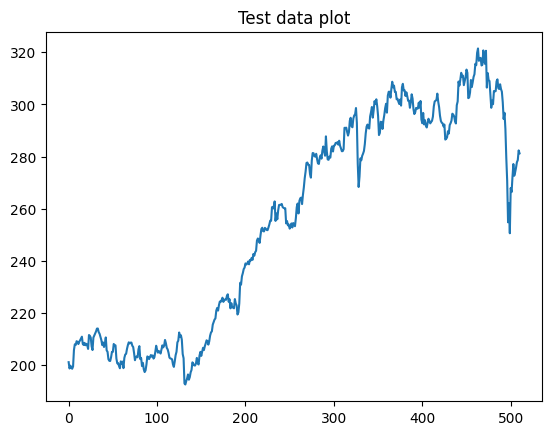

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 1.42888927e+01  4.22727600e+06  2.59524865e+10 -3.51560694e-02
  1.45781390e+01  4.68376428e+01  2.29861783e-02]
[4.97388020e+01 6.15352436e+06 9.03390915e+10 3.86367867e-04
 4.94833246e+01 5.34195558e+01 1.49587969e-02]
[4.84358438e+01 3.98143043e+06 8.79725677e+10 1.67371315e-02
 4.81248602e+01 1.18980773e+01 7.11353410e-03]
[-0.73189412 -0.48380812 -0.73189412 -2.12356802 -0.72530467 -0.55319132
  1.12846601]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 1.8049874318682628
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

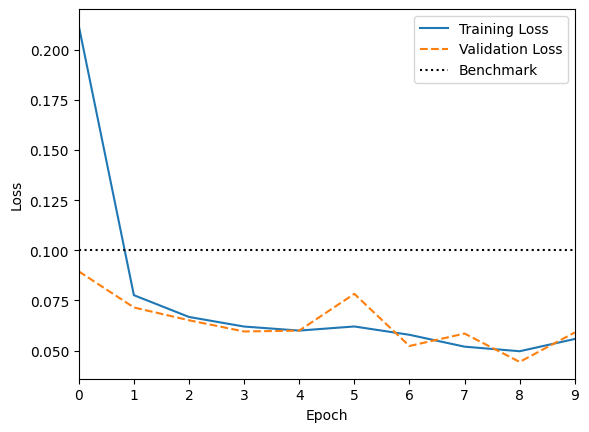

variance of returns for old data:  0.0023618124020945833
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.8971e+02, 2.7538e+06, 3.4457e+11, 1.0490e-03, 1.8803e+02, 5.5811e+01,
         1.3404e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(200.4973)
windows last2 price:  tensor(200.2121)
windows last3 price:  tensor(200.9727)
period from idx:  0  to idx  10
prediction at 10:  tensor(190.2411)
last price from test data:  200.497314453125
real price 10 steps forward:  tensor(208.9583)
kelly weight:  {tensor(-1.0526, dtype=torch.float64)}
 
lw mean tensor([[1.9172e+02, 2.7897e+06, 3.4822e+11, 1.3442e-03, 1.8988e+02, 5.5602e+01,
         1.2941e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(208.9583)
windows last2 price:  tensor(209.1960)
windows last3 price:  tensor(207.7700)
period from idx:  10  to idx  20
prediction at 10:  tensor(194.4334)

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(205.9656)
windows last2 price:  tensor(207.4616)
windows last3 price:  tensor(205.0487)
period from idx:  100  to idx  110
prediction at 10:  tensor(205.5798)
last price from test data:  tensor(205.9656)
real price 10 steps forward:  tensor(208.4268)
kelly weight:  {tensor(-0.0385, dtype=torch.float64)}
 
lw mean tensor([[2.0585e+02, 2.6381e+06, 3.7389e+11, 1.4567e-05, 2.0556e+02, 5.2266e+01,
         9.3554e-03]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(208.4268)
windows last2 price:  tensor(209.6815)
windows last3 price:  tensor(207.5099)
period from idx:  110  to idx  120
prediction at 10:  tensor(206.1078)
last price from test data:  tensor(208.4268)
real price 10 steps forward:  tensor(201.4293)
kelly weight:  {tensor(-0.2289, dtype=torch.float64)}
 
lw mean tensor([[ 2.0526e+02,  2.6182e+06,  3.7281e+11, -2.8914e-04,  2.0568e+02,
          4.

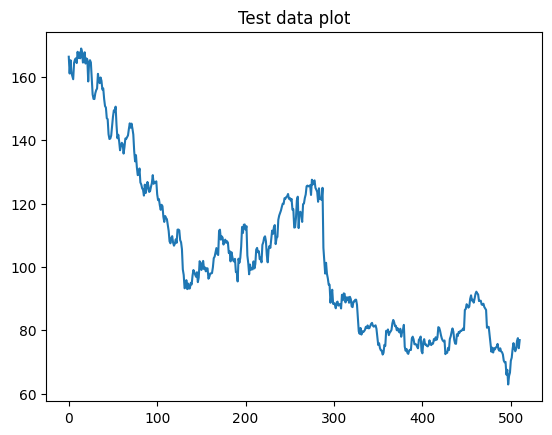

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 2.43462448e+01  2.27230000e+04  5.92142043e+09 -4.50000037e-02
  2.38618716e+01  5.09900698e+01  4.06852812e-02]
[7.68312681e+01 1.04726606e+06 1.86866699e+10 1.06013781e-04
 7.66227077e+01 5.26021986e+01 2.01245240e-02]
[7.41735254e+01 8.43961452e+05 1.80402617e+10 2.36007141e-02
 7.38972251e+01 1.31802730e+01 1.09080014e-02]
[-0.7075978  -1.21396902 -0.7075978  -1.9112141  -0.71397588 -0.12231376
  1.88492433]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 4.007733739750541
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

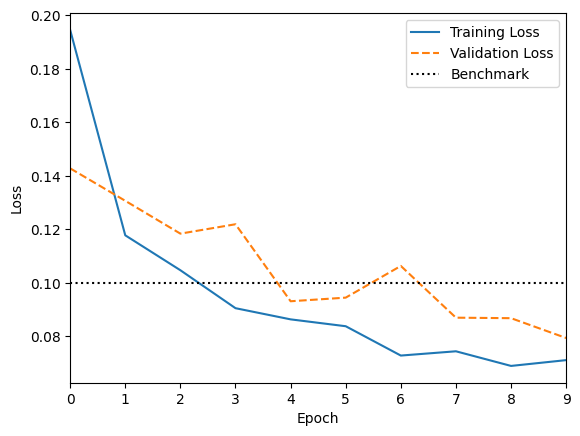

variance of returns for old data:  0.0056988454302464644
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.5624e+02, 9.6997e+05, 3.8001e+10, 1.0396e-03, 1.5600e+02, 5.0741e+01,
         3.2598e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(165.9000)
windows last2 price:  tensor(163.7500)
windows last3 price:  tensor(162.5500)
period from idx:  0  to idx  10
prediction at 10:  tensor(155.3754)
last price from test data:  165.89999389648438
real price 10 steps forward:  tensor(167.8500)
kelly weight:  {tensor(-0.8404, dtype=torch.float64)}
 
lw mean tensor([[1.5652e+02, 9.4153e+05, 3.8069e+10, 1.4447e-03, 1.5638e+02, 5.0737e+01,
         3.1059e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(167.8500)
windows last2 price:  tensor(164.3000)
windows last3 price:  tensor(165.8000)
period from idx:  10  to idx  20
prediction at 10:  tensor(161.270

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(97.2600)
windows last2 price:  tensor(94.4600)
windows last3 price:  tensor(94.9800)
period from idx:  140  to idx  150
prediction at 10:  tensor(114.7602)
last price from test data:  tensor(97.2600)
real price 10 steps forward:  tensor(99.0400)
kelly weight:  {tensor(2.3835, dtype=torch.float64)}
 
lw mean tensor([[ 1.1976e+02,  1.1422e+06,  2.9128e+10, -3.7936e-03,  1.2450e+02,
          3.6198e+01,  1.7829e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(99.0400)
windows last2 price:  tensor(101.3000)
windows last3 price:  tensor(101.8000)
period from idx:  150  to idx  160
prediction at 10:  tensor(111.7754)
last price from test data:  tensor(99.0400)
real price 10 steps forward:  tensor(97.9400)
kelly weight:  {tensor(1.7034, dtype=torch.float64)}
 
lw mean tensor([[ 1.1537e+02,  1.1482e+06,  2.8060e+10, -3.3336e-03,  1.1952e+02,
          3.705

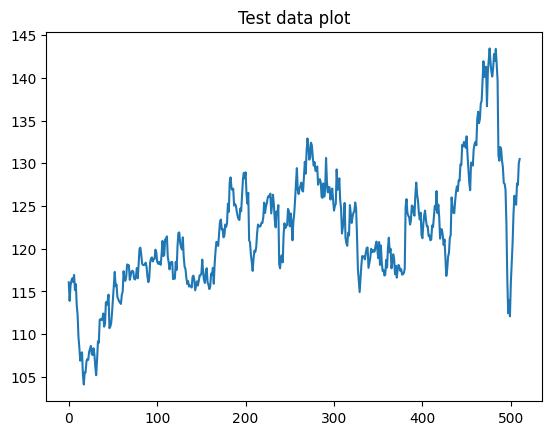

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 2.91987610e+01  5.18249200e+06  1.01166118e+11 -4.06524032e-03
  2.88382475e+01  5.10001816e+01  2.12955097e-02]
[6.36501992e+01 9.77172813e+06 2.20531397e+11 4.23734262e-04
 6.35298726e+01 5.18957033e+01 1.78826527e-02]
[2.24390330e+01 6.66543003e+06 7.77454174e+10 2.07998034e-02
 2.23296478e+01 1.12943197e+01 9.64712210e-03]
[-1.53533524 -0.68851314 -1.53533524 -0.21581813 -1.55361273 -0.07928956
  0.35376944]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 2.5158508066897807
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

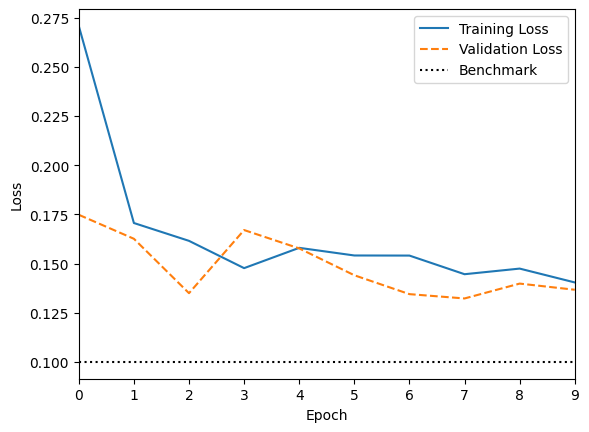

variance of returns for old data:  0.0032984009903951005
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.1529e+02, 5.3672e+06, 3.9943e+11, 7.6886e-04, 1.1476e+02, 6.0455e+01,
         1.3149e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(112.8511)
windows last2 price:  tensor(111.9241)
windows last3 price:  tensor(112.9299)
period from idx:  0  to idx  10
prediction at 10:  tensor(112.6746)
last price from test data:  112.8510513305664
real price 10 steps forward:  tensor(112.2397)
kelly weight:  {tensor(-0.0272, dtype=torch.float64)}
 
lw mean tensor([[1.1612e+02, 5.3980e+06, 4.0232e+11, 3.3082e-04, 1.1542e+02, 5.9189e+01,
         1.4535e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(112.2397)
windows last2 price:  tensor(113.4033)
windows last3 price:  tensor(115.8686)
period from idx:  10  to idx  20
prediction at 10:  tensor(114.1891

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(116.6969)
windows last2 price:  tensor(115.4544)
windows last3 price:  tensor(115.6713)
period from idx:  140  to idx  150
prediction at 10:  tensor(116.5607)
last price from test data:  tensor(116.6969)
real price 10 steps forward:  tensor(117.1111)
kelly weight:  {tensor(-0.0203, dtype=torch.float64)}
 
lw mean tensor([[1.1762e+02, 3.4239e+06, 4.0754e+11, 2.8916e-04, 1.1725e+02, 5.3334e+01,
         9.1660e-03]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(117.1111)
windows last2 price:  tensor(116.8941)
windows last3 price:  tensor(116.8744)
period from idx:  150  to idx  160
prediction at 10:  tensor(117.3678)
last price from test data:  tensor(117.1111)
real price 10 steps forward:  tensor(115.6319)
kelly weight:  {tensor(0.0382, dtype=torch.float64)}
 
lw mean tensor([[1.1780e+02, 4.5859e+06, 4.0814e+11, 1.2223e-04, 1.1758e+02, 5.2338e+01,
      

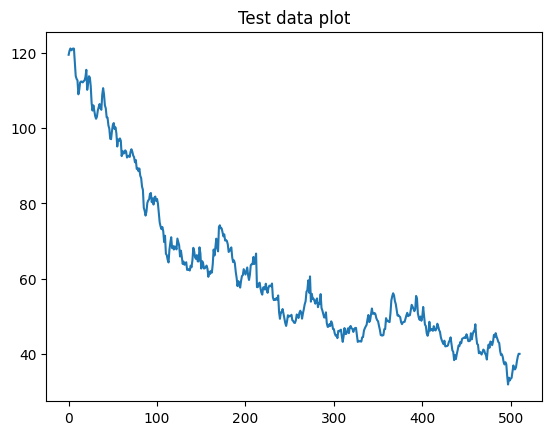

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 2.87091583e-01  1.26169500e+06  5.11867076e+08 -9.09040599e-03
  2.96441962e-01  3.32485079e+01  1.35629413e-02]
[1.62677378e+01 2.26003203e+06 2.90044009e+10 1.51975353e-03
 1.60973341e+01 5.47787069e+01 1.84971257e-02]
[2.62400644e+01 3.40652226e+06 4.67844613e+10 2.10304967e-02
 2.59489058e+01 1.22946042e+01 8.33920422e-03]
[-0.60901703 -0.29306635 -0.60901703 -0.50451303 -0.60892325 -1.7511909
 -0.59168528]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 1.0281243607827018
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

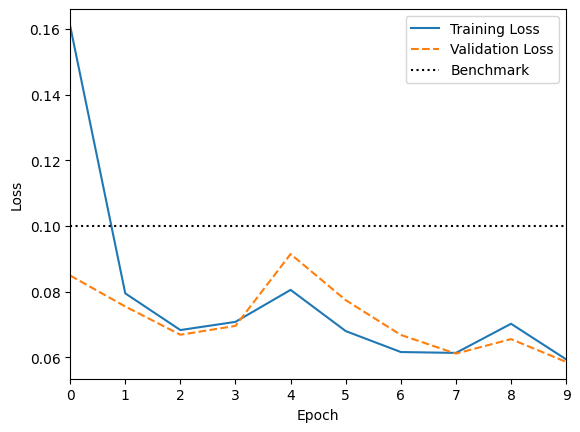

variance of returns for old data:  0.0039849556449280035
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.0665e+02, 3.0885e+06, 1.9015e+11, 2.2566e-03, 1.0476e+02, 5.4604e+01,
         2.7347e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(117.4972)
windows last2 price:  tensor(114.7922)
windows last3 price:  tensor(113.9561)
period from idx:  0  to idx  10
prediction at 10:  tensor(107.4758)
last price from test data:  117.49720764160156
real price 10 steps forward:  tensor(112.6281)
kelly weight:  {tensor(-1.3511, dtype=torch.float64)}
 
lw mean tensor([[1.0847e+02, 3.0484e+06, 1.9340e+11, 1.0346e-03, 1.0684e+02, 5.4400e+01,
         2.6710e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(112.6281)
windows last2 price:  tensor(113.0216)
windows last3 price:  tensor(113.8085)
period from idx:  10  to idx  20
prediction at 10:  tensor(109.039

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(62.7475)
windows last2 price:  tensor(66.8238)
windows last3 price:  tensor(68.3673)
period from idx:  150  to idx  160
prediction at 10:  tensor(77.6709)
last price from test data:  tensor(62.7475)
real price 10 steps forward:  tensor(61.3030)
kelly weight:  {tensor(3.7676, dtype=torch.float64)}
 
lw mean tensor([[ 7.4761e+01,  4.7949e+06,  1.3329e+11, -3.8622e-03,  7.8031e+01,
          3.6124e+01,  2.1480e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(61.3030)
windows last2 price:  tensor(61.9164)
windows last3 price:  tensor(60.5511)
period from idx:  160  to idx  170
prediction at 10:  tensor(74.2390)
last price from test data:  tensor(61.3030)
real price 10 steps forward:  tensor(73.7892)
kelly weight:  {tensor(3.3428, dtype=torch.float64)}
 
lw mean tensor([[ 7.2146e+01,  5.1944e+06,  1.2863e+11, -2.0472e-03,  7.4759e+01,
          3.8128e+0

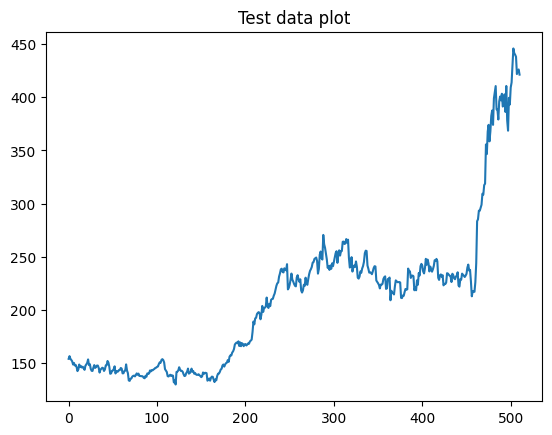

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 8.85961723e+00  5.97897000e+05  4.66473023e+09 -1.44929227e-02
  9.26677098e+00  2.49055810e+01  1.22769308e-02]
[ 3.69101873e+01  9.00207572e+05  1.94338042e+10 -6.08866846e-04
  3.67857205e+01  5.21299401e+01  1.79999332e-02]
[2.50163810e+01 9.23207271e+05 1.31715248e+10 2.02127570e-02
 2.48841757e+01 1.24480549e+01 9.11708816e-03]
[-1.12128809 -0.32745688 -1.12128809 -0.6868957  -1.1058815  -2.18703719
 -0.62772262]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 1.786404407866623
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

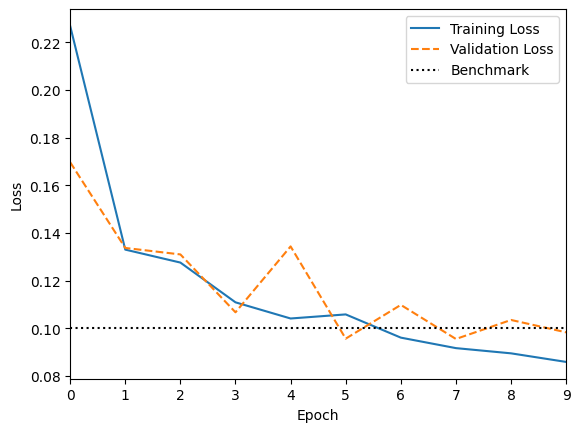

variance of returns for old data:  0.004352810580857101
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.2064e+02, 1.7077e+06, 6.3521e+10, 5.7286e-03, 1.1466e+02, 6.7309e+01,
         1.8639e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(159.7236)
windows last2 price:  tensor(160.3179)
windows last3 price:  tensor(158.3368)
period from idx:  0  to idx  10
prediction at 10:  tensor(129.1593)
last price from test data:  159.7235870361328
real price 10 steps forward:  tensor(142.5378)
kelly weight:  {tensor(-2.9004, dtype=torch.float64)}
 
lw mean tensor([[1.2617e+02, 1.7629e+06, 6.6432e+10, 4.3933e-03, 1.2073e+02, 6.6505e+01,
         1.7636e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(142.5378)
windows last2 price:  tensor(146.3018)
windows last3 price:  tensor(148.2829)
period from idx:  10  to idx  20
prediction at 10:  tensor(125.8408)

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(142.0921)
windows last2 price:  tensor(144.8656)
windows last3 price:  tensor(141.6463)
period from idx:  140  to idx  150
prediction at 10:  tensor(141.8316)
last price from test data:  tensor(142.0921)
real price 10 steps forward:  tensor(136.8423)
kelly weight:  {tensor(-0.0278, dtype=torch.float64)}
 
lw mean tensor([[ 1.4130e+02,  1.1329e+06,  7.4395e+10, -2.7944e-04,  1.4178e+02,
          4.9459e+01,  1.8138e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(136.8423)
windows last2 price:  tensor(137.9318)
windows last3 price:  tensor(138.5757)
period from idx:  150  to idx  160
prediction at 10:  tensor(141.1474)
last price from test data:  tensor(136.8423)
real price 10 steps forward:  tensor(133.5240)
kelly weight:  {tensor(0.4768, dtype=torch.float64)}
 
lw mean tensor([[ 1.4072e+02,  1.1324e+06,  7.4091e+10, -6.4536e-04,  1.4130e+02,
      

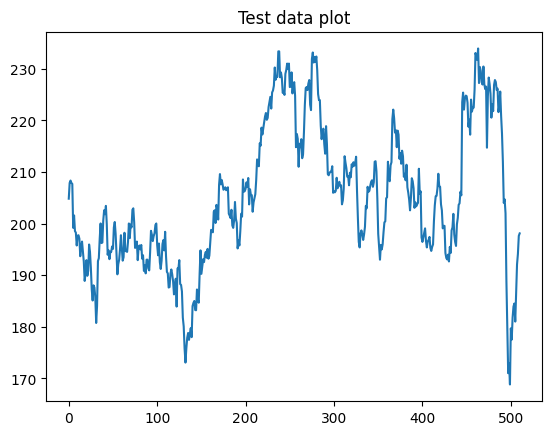

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 2.09454212e+01  6.67306000e+06  2.62737273e+10 -3.44828405e-02
  2.33105825e+01  2.62368658e+01  2.62327041e-02]
[7.23633028e+01 1.23744454e+07 9.07718045e+10 8.86228559e-04
 7.21439554e+01 5.20089094e+01 1.91077569e-02]
[4.85015974e+01 1.47990896e+07 6.08399196e+10 2.09496170e-02
 4.83029636e+01 1.12044221e+01 8.40232030e-03]
[-1.06012759 -0.38525244 -1.06012759 -1.68829192 -1.01098088 -2.30016715
  0.84797376]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 3.3491262589459834
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

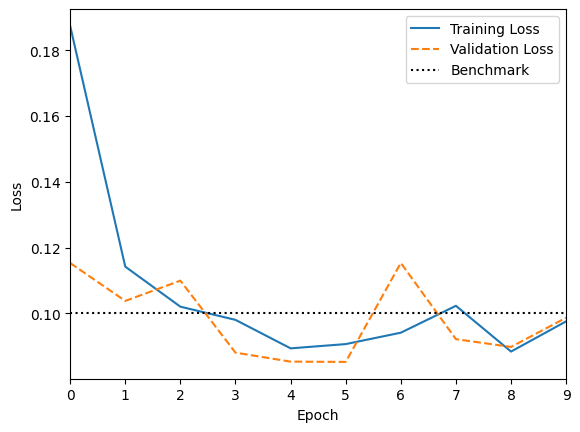

variance of returns for old data:  0.003517694307679755
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.9112e+02, 2.0402e+06, 2.3974e+11, 1.5770e-03, 1.8869e+02, 5.6700e+01,
         1.7150e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(203.8165)
windows last2 price:  tensor(204.1867)
windows last3 price:  tensor(199.9290)
period from idx:  0  to idx  10
prediction at 10:  tensor(191.0937)
last price from test data:  203.81646728515625
real price 10 steps forward:  tensor(197.6598)
kelly weight:  {tensor(-1.0525, dtype=torch.float64)}
 
lw mean tensor([[1.9350e+02, 2.1597e+06, 2.4273e+11, 1.0960e-03, 1.9137e+02, 5.5644e+01,
         1.7057e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(197.6598)
windows last2 price:  tensor(195.7638)
windows last3 price:  tensor(198.2629)
period from idx:  10  to idx  20
prediction at 10:  tensor(194.3928

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(187.4687)
windows last2 price:  tensor(186.2837)
windows last3 price:  tensor(188.7959)
period from idx:  120  to idx  130
prediction at 10:  tensor(194.3965)
last price from test data:  tensor(187.4687)
real price 10 steps forward:  tensor(180.0742)
kelly weight:  {tensor(0.6231, dtype=torch.float64)}
 
lw mean tensor([[ 1.9413e+02,  1.7314e+06,  2.4351e+11, -2.0587e-04,  1.9438e+02,
          4.9026e+01,  1.4169e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(180.0742)
windows last2 price:  tensor(181.7807)
windows last3 price:  tensor(186.8525)
period from idx:  130  to idx  140
prediction at 10:  tensor(193.9370)
last price from test data:  tensor(180.0742)
real price 10 steps forward:  tensor(184.0085)
kelly weight:  {tensor(1.2980, dtype=torch.float64)}
 
lw mean tensor([[ 1.9248e+02,  1.7981e+06,  2.4145e+11, -8.6776e-04,  1.9378e+02,
       

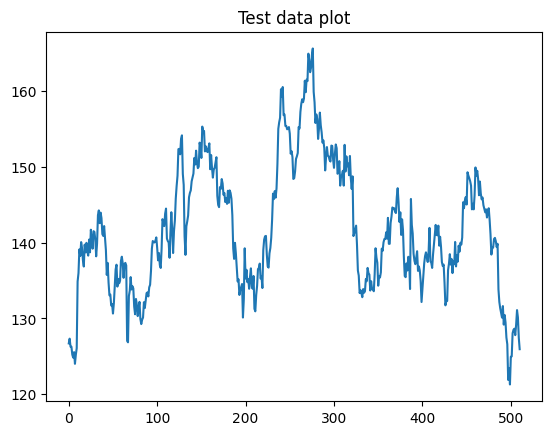

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 5.52285314e-01  3.10878280e+07  3.53173186e+08 -1.11606881e-02
  6.08324277e-01  2.75111428e+01  2.82628697e-02]
[3.24437152e+01 1.62620066e+07 2.07469762e+10 7.07471922e-04
 3.22077415e+01 5.41442903e+01 1.66624072e-02]
[4.47168429e+01 1.83761272e+07 2.85953464e+10 1.86977528e-02
 4.44653555e+01 1.24771992e+01 9.05837283e-03]
[-0.71318608  0.80679793 -0.71318608 -0.63473724 -0.71065253 -2.13454535
  1.28063425]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 1.41575951442001
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

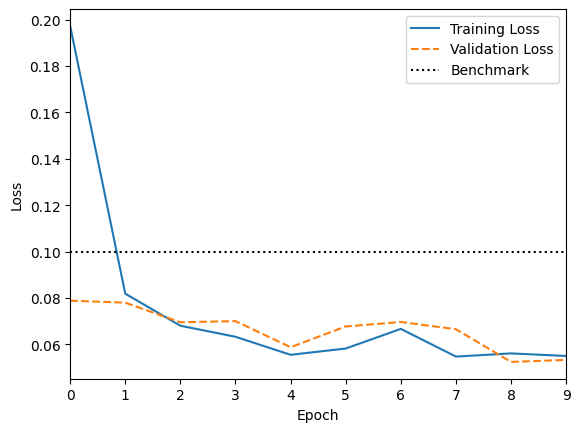

variance of returns for old data:  0.0033741001304404953
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[ 1.3376e+02,  1.6181e+06,  8.5538e+10, -1.1182e-04,  1.3384e+02,
          4.9610e+01,  1.5943e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(127.5759)
windows last2 price:  tensor(127.6239)
windows last3 price:  tensor(130.2647)
period from idx:  0  to idx  10
prediction at 10:  tensor(133.2771)
last price from test data:  127.57587432861328
real price 10 steps forward:  tensor(134.8742)
kelly weight:  {tensor(0.7693, dtype=torch.float64)}
 
lw mean tensor([[1.3317e+02, 1.6958e+06, 8.5162e+10, 2.5180e-04, 1.3365e+02, 4.8467e+01,
         1.6086e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(134.8742)
windows last2 price:  tensor(126.0874)
windows last3 price:  tensor(125.2231)
period from idx:  10  to idx  20
prediction at 10:  tensor(1

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


tensor(138.6921)
last price from test data:  tensor(148.5584)
real price 10 steps forward:  tensor(151.1512)
kelly weight:  {tensor(-1.1434, dtype=torch.float64)}
 
lw mean tensor([[1.3987e+02, 1.2366e+06, 8.9441e+10, 1.5812e-03, 1.3855e+02, 5.4223e+01,
         1.5349e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(151.1512)
windows last2 price:  tensor(152.5437)
windows last3 price:  tensor(153.1679)
period from idx:  150  to idx  160
prediction at 10:  tensor(141.2481)
last price from test data:  tensor(151.1512)
real price 10 steps forward:  tensor(149.6628)
kelly weight:  {tensor(-1.1279, dtype=torch.float64)}
 
lw mean tensor([[1.4161e+02, 1.2658e+06, 9.0555e+10, 9.2489e-04, 1.3996e+02, 5.5158e+01,
         1.5184e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(149.6628)
windows last2 price:  tensor(153.0718)
windows last3 price:  tensor(152.4957)
period from idx:  160  to idx  170
p

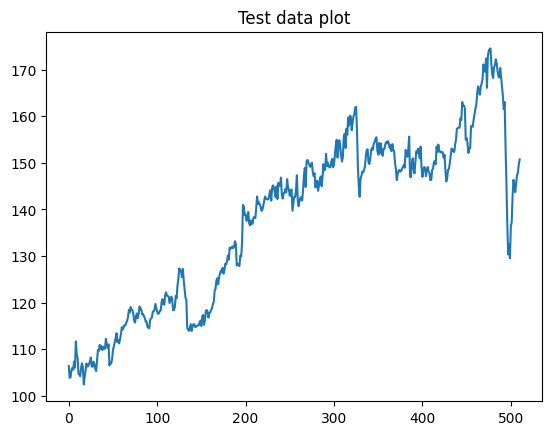

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 1.40866518e+01  2.74833100e+06  2.75132026e+10 -2.50000215e-02
  1.50934836e+01  2.43184247e+01  1.42116058e-02]
[4.30564334e+01 6.44588047e+06 8.40952410e+10 5.78120311e-04
 4.29147939e+01 5.27030453e+01 1.90141090e-02]
[2.35272837e+01 4.37820607e+06 4.59520782e+10 2.23915406e-02
 2.33798391e+01 1.13373924e+01 1.25929507e-02]
[-1.23132708 -0.84453528 -1.23132708 -1.14231272 -1.18997014 -2.50362867
 -0.38136441]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 1.7391611047736977
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

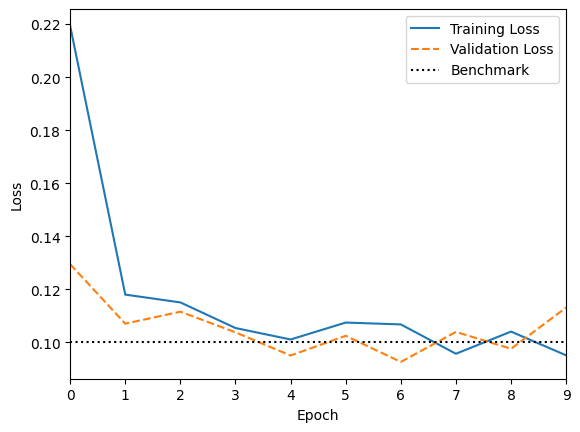

variance of returns for old data:  0.0040809755603019495
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[ 1.0615e+02,  4.1506e+06,  2.0733e+11, -3.0819e-05,  1.0651e+02,
          5.2263e+01,  1.3876e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(101.7616)
windows last2 price:  tensor(101.3438)
windows last3 price:  tensor(101.6223)
period from idx:  0  to idx  10
prediction at 10:  tensor(106.3037)
last price from test data:  101.76160430908205
real price 10 steps forward:  tensor(108.1681)
kelly weight:  {tensor(0.6987, dtype=torch.float64)}
 
lw mean tensor([[ 1.0639e+02,  4.4547e+06,  2.0780e+11, -4.6939e-06,  1.0631e+02,
          5.2289e+01,  1.4683e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(108.1681)
windows last2 price:  tensor(108.9573)
windows last3 price:  tensor(111.6964)
period from idx:  10  to idx  20
prediction at 10:  t

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


tensor(124.8344)
windows last2 price:  tensor(127.2484)
windows last3 price:  tensor(125.4843)
period from idx:  130  to idx  140
prediction at 10:  tensor(119.0128)
last price from test data:  tensor(124.8344)
real price 10 steps forward:  tensor(114.8996)
kelly weight:  {tensor(-0.7300, dtype=torch.float64)}
 
lw mean tensor([[1.1712e+02, 2.9395e+06, 2.2875e+11, 4.9136e-04, 1.1622e+02, 5.6940e+01,
         9.9642e-03]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(114.8996)
windows last2 price:  tensor(113.9247)
windows last3 price:  tensor(115.4103)
period from idx:  140  to idx  150
prediction at 10:  tensor(116.8200)
last price from test data:  tensor(114.8996)
real price 10 steps forward:  tensor(114.9925)
kelly weight:  {tensor(0.2616, dtype=torch.float64)}
 
lw mean tensor([[1.1771e+02, 2.8510e+06, 2.2991e+11, 5.1248e-04, 1.1716e+02, 5.5598e+01,
         1.0150e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
wind

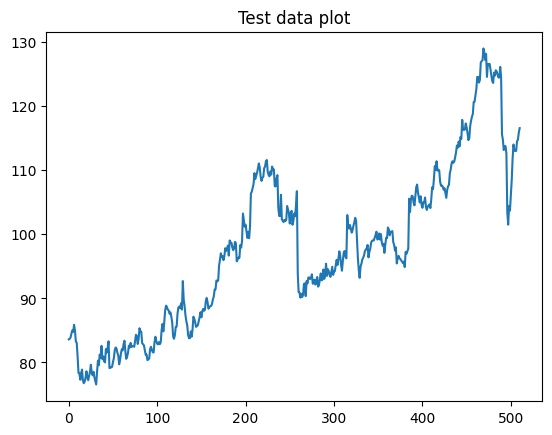

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 1.21157541e+01  4.13292800e+06  2.35624767e+10 -4.83058221e-03
  1.24951056e+01  4.12187009e+01  2.13615980e-02]
[ 4.47880332e+01  5.75924771e+06  8.71028727e+10 -8.47607803e-06
  4.46840298e+01  5.18886269e+01  1.54202274e-02]
[2.35422877e+01 3.98442241e+06 4.57845711e+10 1.75133239e-02
 2.35012240e+01 1.09894326e+01 8.37162375e-03]
[-1.38781241 -0.4081695  -1.38781241 -0.27533929 -1.36967012 -0.97092602
  0.70970349]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 1.5889924163727656
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

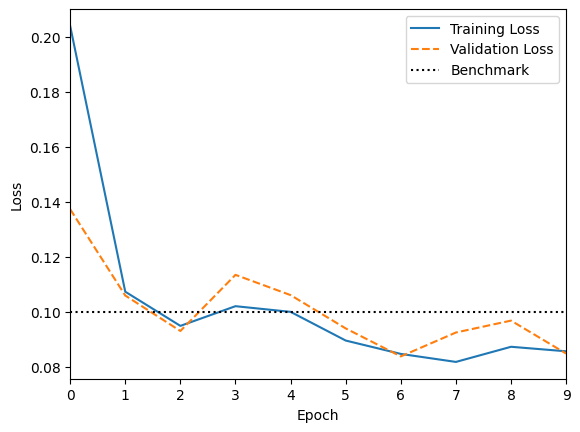

variance of returns for old data:  0.002430514317271405
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[ 8.7923e+01,  5.6893e+06,  1.7099e+11, -8.6909e-04,  8.8717e+01,
          5.0515e+01,  1.4468e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(80.8749)
windows last2 price:  tensor(80.8035)
windows last3 price:  tensor(81.2143)
period from idx:  0  to idx  10
prediction at 10:  tensor(87.7863)
last price from test data:  80.87493133544922
real price 10 steps forward:  tensor(80.9285)
kelly weight:  {tensor(1.7334, dtype=torch.float64)}
 
lw mean tensor([[ 8.7479e+01,  5.9552e+06,  1.7013e+11, -1.0545e-03,  8.8020e+01,
          5.0069e+01,  1.5456e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(80.9285)
windows last2 price:  tensor(83.0718)
windows last3 price:  tensor(83.2862)
period from idx:  10  to idx  20
prediction at 10:  tensor(87.4

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(89.7965)
windows last2 price:  tensor(92.6990)
windows last3 price:  tensor(88.2516)
period from idx:  130  to idx  140
prediction at 10:  tensor(84.6709)
last price from test data:  tensor(89.7965)
real price 10 steps forward:  tensor(85.1616)
kelly weight:  {tensor(-1.1578, dtype=torch.float64)}
 
lw mean tensor([[8.3771e+01, 4.7876e+06, 1.6292e+11, 6.9004e-04, 8.3161e+01, 5.4193e+01,
         1.2757e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(85.1616)
windows last2 price:  tensor(84.0363)
windows last3 price:  tensor(84.8401)
period from idx:  140  to idx  150
prediction at 10:  tensor(83.5415)
last price from test data:  tensor(85.1616)
real price 10 steps forward:  tensor(87.0370)
kelly weight:  {tensor(-0.3859, dtype=torch.float64)}
 
lw mean tensor([[8.4365e+01, 4.5726e+06, 1.6407e+11, 9.0561e-04, 8.3833e+01, 5.4159e+01,
         1.2704e-

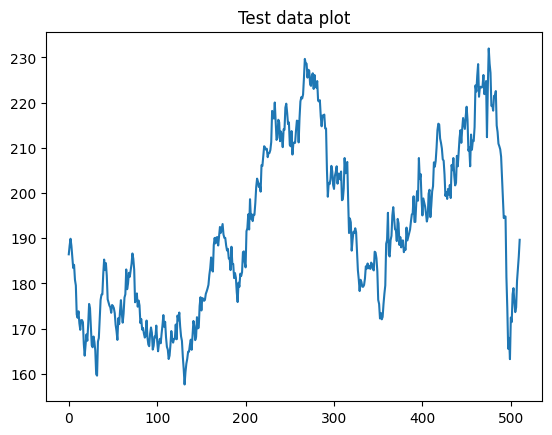

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 2.17024612e+01  6.15515200e+06  9.25436352e+09 -1.22249355e-02
  2.35423344e+01  3.48655619e+01  2.78043304e-02]
[8.81395358e+01 4.98076551e+06 3.75844608e+10 4.64386430e-04
 8.79584948e+01 5.18137351e+01 1.90319413e-02]
[4.84620500e+01 5.59903952e+06 2.06651874e+10 2.06466316e-02
 4.83892366e+01 1.13027671e+01 7.72372627e-03]
[-1.37090929  0.20974785 -1.37090929 -0.61459526 -1.33120845 -1.49947116
  1.13577163]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 3.944991100417531
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

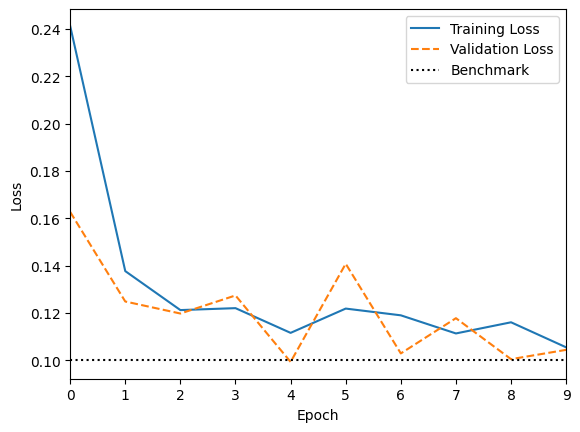

variance of returns for old data:  0.0034815451348286087
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.6867e+02, 1.5310e+06, 7.1925e+10, 1.8507e-03, 1.6616e+02, 5.4830e+01,
         2.2621e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(182.4845)
windows last2 price:  tensor(184.3917)
windows last3 price:  tensor(180.9029)
period from idx:  0  to idx  10
prediction at 10:  tensor(168.3220)
last price from test data:  182.4844970703125
real price 10 steps forward:  tensor(172.3904)
kelly weight:  {tensor(-1.3153, dtype=torch.float64)}
 
lw mean tensor([[1.7127e+02, 1.5595e+06, 7.3035e+10, 9.7609e-04, 1.6897e+02, 5.4268e+01,
         2.2474e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(172.3904)
windows last2 price:  tensor(173.1347)
windows last3 price:  tensor(179.5540)
period from idx:  10  to idx  20
prediction at 10:  tensor(170.3150

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(168.3900)
windows last2 price:  tensor(165.3199)
windows last3 price:  tensor(167.5527)
period from idx:  140  to idx  150
prediction at 10:  tensor(170.8869)
last price from test data:  tensor(168.3900)
real price 10 steps forward:  tensor(174.0185)
kelly weight:  {tensor(0.2513, dtype=torch.float64)}
 
lw mean tensor([[1.7080e+02, 1.3525e+06, 7.2834e+10, 4.7196e-05, 1.7142e+02, 4.8445e+01,
         1.4293e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(174.0185)
windows last2 price:  tensor(176.9490)
windows last3 price:  tensor(174.9953)
period from idx:  150  to idx  160
prediction at 10:  tensor(171.3945)
last price from test data:  tensor(174.0185)
real price 10 steps forward:  tensor(183.3683)
kelly weight:  {tensor(-0.2556, dtype=torch.float64)}
 
lw mean tensor([[1.7143e+02, 1.3247e+06, 7.3103e+10, 6.5909e-04, 1.7101e+02, 5.0186e+01,
      

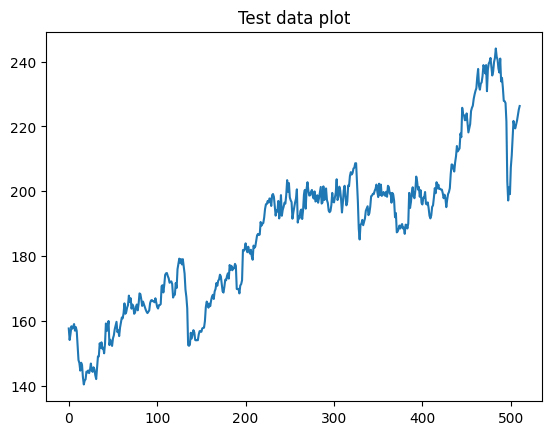

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 2.53812160e+01  1.73165900e+06  2.85297571e+10 -3.68850819e-02
  2.71038941e+01  2.58662916e+01  1.72791768e-02]
[6.97026467e+01 3.77096192e+06 7.83492633e+10 3.50105452e-04
 6.95269782e+01 5.26685092e+01 1.78471455e-02]
[3.83560261e+01 3.64043353e+06 4.31140930e+10 2.07132081e-02
 3.82371523e+01 1.15863509e+01 1.20136638e-02]
[-1.15552718 -0.56018134 -1.15552718 -1.79765428 -1.10947289 -2.31325789
 -0.0472769 ]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 2.7294027934903684
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

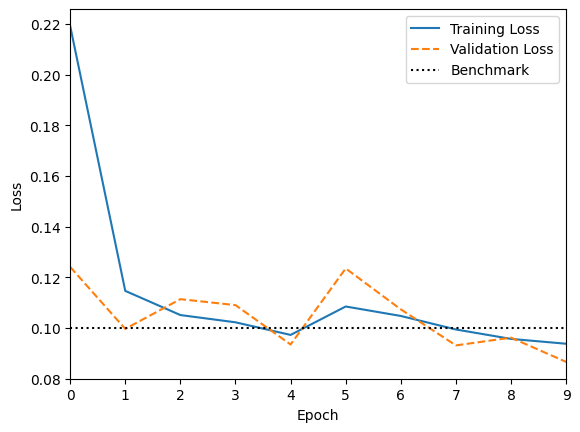

variance of returns for old data:  0.004099370495744535
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.5186e+02, 3.4398e+06, 1.7070e+11, 1.5248e-03, 1.5062e+02, 5.9937e+01,
         1.4120e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(154.3654)
windows last2 price:  tensor(151.4568)
windows last3 price:  tensor(152.3551)
period from idx:  0  to idx  10
prediction at 10:  tensor(147.5465)
last price from test data:  154.36537170410156
real price 10 steps forward:  tensor(152.2695)
kelly weight:  {tensor(-0.6899, dtype=torch.float64)}
 
lw mean tensor([[1.5396e+02, 3.4698e+06, 1.7306e+11, 1.0141e-03, 1.5217e+02, 5.9192e+01,
         1.4743e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(152.2695)
windows last2 price:  tensor(156.8889)
windows last3 price:  tensor(158.0866)
period from idx:  10  to idx  20
prediction at 10:  tensor(151.8969

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(155.8196)
windows last2 price:  tensor(154.5365)
windows last3 price:  tensor(156.3329)
period from idx:  140  to idx  150
prediction at 10:  tensor(162.1499)
last price from test data:  tensor(155.8196)
real price 10 steps forward:  tensor(156.6323)
kelly weight:  {tensor(0.6345, dtype=torch.float64)}
 
lw mean tensor([[1.6491e+02, 2.2385e+06, 1.8536e+11, 2.1796e-04, 1.6477e+02, 5.3740e+01,
         1.3364e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(156.6323)
windows last2 price:  tensor(156.7606)
windows last3 price:  tensor(156.8462)
period from idx:  150  to idx  160
prediction at 10:  tensor(162.7291)
last price from test data:  tensor(156.6323)
real price 10 steps forward:  tensor(164.5452)
kelly weight:  {tensor(0.6079, dtype=torch.float64)}
 
lw mean tensor([[1.6535e+02, 2.3285e+06, 1.8586e+11, 3.0365e-04, 1.6497e+02, 5.3357e+01,
       

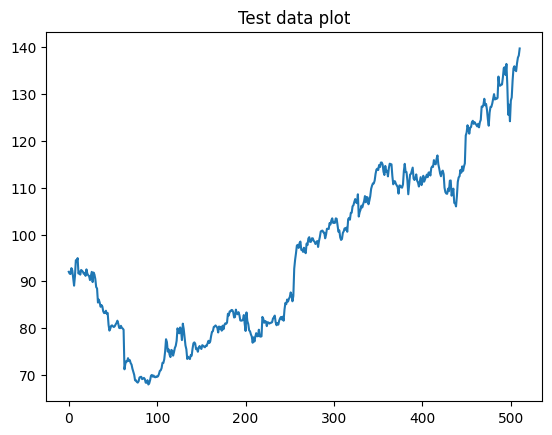

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 4.89801369e+01  1.16962100e+06  3.34324716e+10 -5.16667485e-02
  4.81021118e+01  4.97850548e+01  3.30417673e-02]
[4.87415296e+01 2.52926638e+06 3.32696049e+10 5.65321441e-04
 4.86742974e+01 5.15672358e+01 1.86639972e-02]
[2.23764234e+01 1.70268541e+06 1.52735208e+10 2.11428471e-02
 2.22854953e+01 1.21623150e+01 9.84466346e-03]
[ 0.01066333 -0.79853     0.01066333 -2.47043692 -0.02567525 -0.14653304
  1.46046334]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 2.059596732906673
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

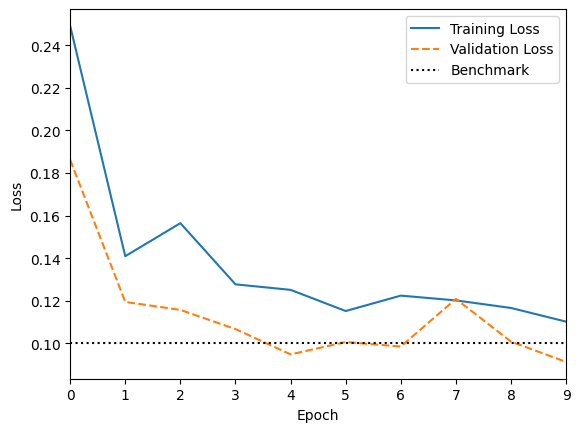

variance of returns for old data:  0.004215555568997165
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[8.2281e+01, 2.6141e+06, 5.6163e+10, 1.3693e-03, 8.1380e+01, 5.4357e+01,
         1.4326e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(92.1649)
windows last2 price:  tensor(91.6855)
windows last3 price:  tensor(91.8163)
period from idx:  0  to idx  10
prediction at 10:  tensor(84.6348)
last price from test data:  92.16488647460938
real price 10 steps forward:  tensor(94.9538)
kelly weight:  {tensor(-1.2584, dtype=torch.float64)}
 
lw mean tensor([[8.3287e+01, 2.6727e+06, 5.6849e+10, 1.6154e-03, 8.2331e+01, 5.4898e+01,
         1.4715e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(94.9538)
windows last2 price:  tensor(94.2566)
windows last3 price:  tensor(94.5180)
period from idx:  10  to idx  20
prediction at 10:  tensor(85.8602)
last pri

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(75.5491)
windows last2 price:  tensor(75.7930)
windows last3 price:  tensor(76.1683)
period from idx:  150  to idx  160
prediction at 10:  tensor(74.1462)
last price from test data:  tensor(75.5491)
real price 10 steps forward:  tensor(77.1626)
kelly weight:  {tensor(-0.2860, dtype=torch.float64)}
 
lw mean tensor([[ 7.3599e+01,  2.7737e+06,  5.0237e+10, -2.3660e-04,  7.3998e+01,
          4.5928e+01,  1.4752e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(77.1626)
windows last2 price:  tensor(76.8249)
windows last3 price:  tensor(77.2939)
period from idx:  160  to idx  170
prediction at 10:  tensor(74.1353)
last price from test data:  tensor(77.1626)
real price 10 steps forward:  tensor(80.3519)
kelly weight:  {tensor(-0.6043, dtype=torch.float64)}
 
lw mean tensor([[7.4166e+01, 2.6821e+06, 5.0624e+10, 1.0990e-03, 7.3809e+01, 5.0036e+01,
         1

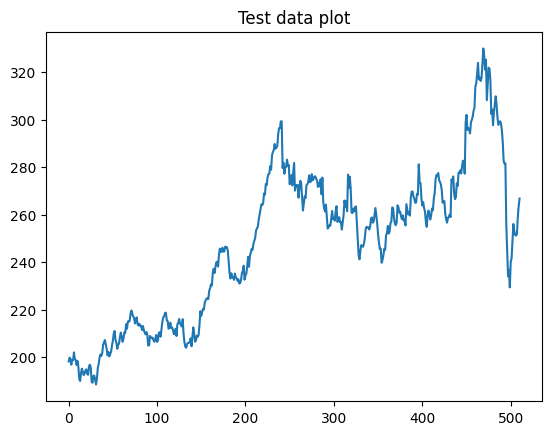

in sequences shape:  (1158, 100, 7)
targets shape:  (1158, 1)
[ 1.63902645e+01  2.72569000e+07  2.60359347e+10 -9.34555413e-03
  1.70300261e+01  3.33200238e+01  1.43622256e-02]
[6.38591120e+01 1.26134862e+07 1.01440197e+11 4.58174791e-04
 6.36085791e+01 5.22003038e+01 1.88114886e-02]
[4.52963132e+01 1.47348226e+07 7.19531920e+10 2.10022480e-02
 4.50200387e+01 1.21040549e+01 8.42715334e-03]
[-1.04796272  0.99379641 -1.04796272 -0.46679427 -1.03461823 -1.55983099
 -0.52796749]
in sequences norm shape:  (1158, 100, 7)
targets norm shape:  (1158, 1)
train loader length:  29
val loader length:  8
Benchmark Celsius: 2.9513242545983065
Normalized Benchmark: 0.1


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  614 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 614 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 614 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

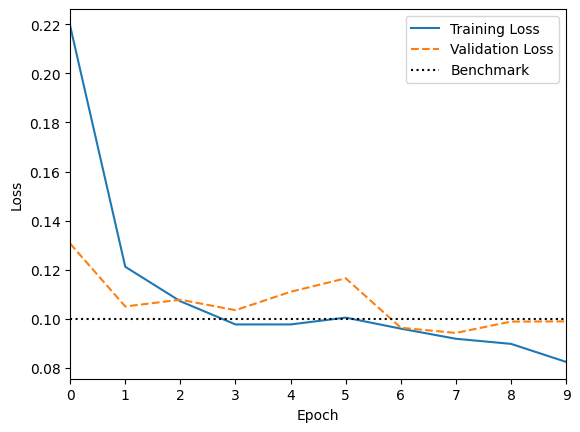

variance of returns for old data:  0.003941567519896487
start window shape:  torch.Size([100, 7])
test data shape torch.Size([511, 7])
lw mean tensor([[1.8334e+02, 3.4441e+06, 2.9124e+11, 1.3831e-03, 1.8175e+02, 5.6521e+01,
         1.4270e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(197.5815)
windows last2 price:  tensor(196.4049)
windows last3 price:  tensor(182.9535)
period from idx:  0  to idx  10
prediction at 10:  tensor(182.7813)
last price from test data:  197.5815277099609
real price 10 steps forward:  tensor(198.4287)
kelly weight:  {tensor(-1.1931, dtype=torch.float64)}
 
lw mean tensor([[1.8570e+02, 3.5956e+06, 2.9499e+11, 1.3221e-03, 1.8370e+02, 5.5873e+01,
         1.6004e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(198.4287)
windows last2 price:  tensor(196.6873)
windows last3 price:  tensor(198.8053)
period from idx:  10  to idx  20
prediction at 10:  tensor(188.4197)

/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/var/folders/p8/l8fck6n93zbbqhtkzpzz3gw00000gn/T/ipykernel_40636/769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(209.7715)
windows last2 price:  tensor(215.9842)
windows last3 price:  tensor(212.8779)
period from idx:  130  to idx  140
prediction at 10:  tensor(210.2762)
last price from test data:  tensor(209.7715)
real price 10 steps forward:  tensor(208.8302)
kelly weight:  {tensor(0.0383, dtype=torch.float64)}
 
lw mean tensor([[2.1029e+02, 2.8250e+06, 3.3404e+11, 1.7715e-04, 2.0934e+02, 5.3259e+01,
         9.9354e-03]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 100, 7])
windows last price:  tensor(208.8302)
windows last2 price:  tensor(204.5943)
windows last3 price:  tensor(207.9360)
period from idx:  140  to idx  150
prediction at 10:  tensor(209.8634)
last price from test data:  tensor(208.8302)
real price 10 steps forward:  tensor(217.3962)
kelly weight:  {tensor(0.0788, dtype=torch.float64)}
 
lw mean tensor([[2.1107e+02, 2.8107e+06, 3.3529e+11, 5.5107e-04, 2.1036e+02, 5.2634e+01,
         1.0096e-02]])
ret shape

In [7]:

tickers = ['VOLV-B.ST', 'KINV-B.ST', 'TEL2-B.ST', 'SCA-B.ST', 'SWED-A.ST']
all_weights = []
tickers = all_tickers
MAPE = []
#tickers = ['TEL2-B.ST']
epochs = 10
for ticker in tickers:
    data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=ticker, no_plotting=True)
    n_features = data_values.shape[1]
    train_loader, val_loader, benchmark, train_mean, train_std = generate_loaders_and_benchmark_new_norm(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )
    cross_attn_lstm_v1 = CrossAttentionLSTMV1(in_dim=n_features, hidden_dim=120, num_hidden_layers=5, out_dim=1, dropout=0.1, num_heads=24)
    #simple_lstm = SimpleLSTM(input_size=n_features, hidden_size=120, num_hidden_layers=3, output_size=1, dropout=0.1)
    #trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)
    chosen_model = cross_attn_lstm_v1
    #chosen_model = simple_lstm
    chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

    trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
    trainer.fit(chosen_model_reg, train_loader, val_loader)
    train_losses = trainer.history.history["train_loss_epoch"]["value"]
    val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
    plot_training(epochs, train_losses, val_losses, benchmark)
    preds_norm, weights = generate_weights_from_predictions_new_norm(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  kelly_clip=15,
                                                  print_values_for_allocation=True)
    all_weights.append(weights)
    print('\n \n \n TEST \n \n')
    test_loader = generate_test_data_loader(data_values[-num_test_points:])
    mape_ticker = test_model_output_percentage_diff_new_norm(chosen_model_reg, test_loader, train_mean, train_std, target_idx)
    MAPE.append(mape_ticker)

all mean abs percent errors per ticker [5.975518703460693, 6.5867085456848145, 6.170032501220703, 7.0662760734558105, 9.635187149047852, 9.730751991271973, 6.649951457977295, 9.355337142944336, 6.3771467208862305, 6.2529473304748535, 11.613849639892578, 3.404426097869873, 14.146440505981445, 9.855464935302734, 5.4306111335754395, 5.270913124084473, 5.123484134674072, 6.638792514801025, 7.528693199157715, 5.491274833679199, 7.244056224822998, 6.005465984344482]
all mean 7.3433331793004815
(22, 510)
(510,)


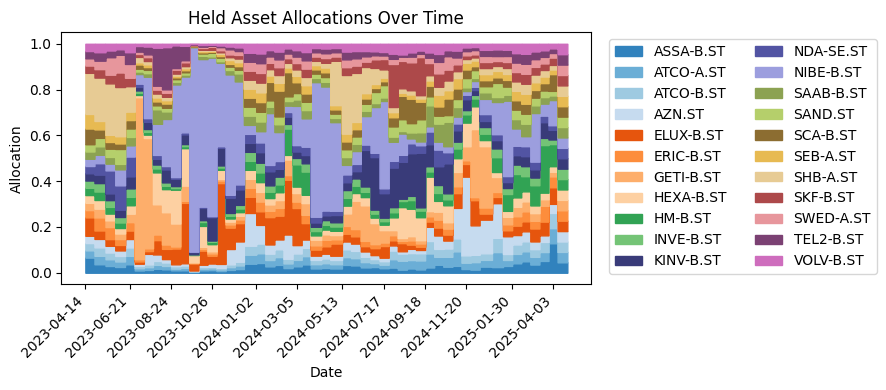

In [13]:


trading_cost = 0.005
print('all mean abs percent errors per ticker',MAPE)
print('all mean', np.mean(MAPE))

test_indices = df.index[-(num_test_points)*22::22]
test_indices = test_indices[:int(horizon*np.floor(num_test_points/horizon))]
#print(all_weights.shape)

all_weights = np.array(all_weights)

np.save('saved_weights\\cross_lstm_511testpoints_10horizon_120hidden_5l_24head_new_norm_100ws_5step_17_04_23.npy', all_weights)

alloc = allocate_from_weights(all_weights, horizon=horizon, num_of_test_points=num_test_points)
print(alloc.shape)
alloc_diff = np.diff(alloc, axis=1)
alloc_diff = np.concatenate([alloc_diff, np.zeros((len(tickers),1))], axis=1)
alloc_diff = 0.5* np.sum(np.abs(alloc_diff), axis=0)
print(alloc_diff.shape)

def plot_allocations(alloc, tickers, dates):
    n_assets, total_steps = alloc.shape
    print(total_steps)
    
    

    # Time axis
    t = np.arange(total_steps)

    # Compute cumulative allocations for stacking
    cumsum = np.cumsum(alloc, axis=0)

    plt.figure(figsize=(20,16))
    # Plot filled areas for each asset
    for i in range(n_assets):
        bottom = cumsum[i-1] if i > 0 else np.zeros_like(t)
        top = cumsum[i]
        plt.fill_between(t, bottom, top, step='post', label=tickers[i])
    
    plt.xlabel('Time Step')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend()

    plt.tight_layout()
    plt.show()
#plot_allocations(alloc, tickers, test_indices)

def plot_allocations(alloc, tickers, dates):
    n_assets, T = alloc.shape
    # Stack allocations
    cumsum = np.cumsum(alloc, axis=0)
    base_cmap = plt.get_cmap('tab20c')
    extra_cmap = plt.get_cmap('tab20b')
    colors = []
    for i in range(n_assets):
        if i < 10:
            colors.append(base_cmap(i))  # tab20 has 20 distinct
        else:
            # pick from hsv evenly for any extras
            colors.append(extra_cmap((i-10) / max(1, n_assets-10)))

    #cmap = plt.get_cmap('tab20', n_assets)
    #colors = [cmap(i) for i in range(n_assets)]

    plt.figure(figsize=(9,4))
    for i, ticker in enumerate(tickers):
        bottom = cumsum[i-1] if i>0 else np.zeros(T)
        top    = cumsum[i]
        # use dates on the x-axis
        plt.fill_between(dates, bottom, top, step='post', label=ticker, color=colors[i])

    # now the ticks are the dates themselves
    plt.xticks(
        dates[::45], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )

    plt.xlabel('Date')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend(ncol=2, bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# call with your alloc, tickers and test_indices as dates:
plot_allocations(alloc, tickers, test_indices)
#np.save('best_allocations.npy',alloc)

510
ret assa 11-12 jul 0.006843340697032293
(510,)
Portfoliot final return:  1.013998432266842
(510,)
Index final return 1.1564944116465998


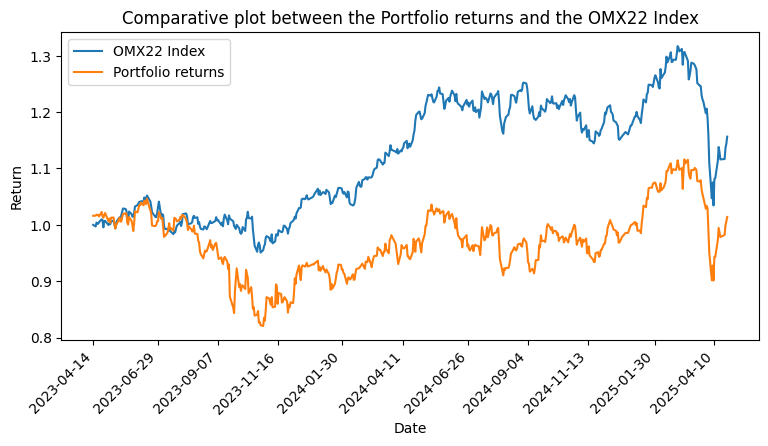

In [12]:


print(len(test_indices))

returns = calculate_asset_returns_cont(df, tickers, num_of_test_points=num_test_points)
print('ret assa 11-12 jul', returns[0,0] )

#print(alloc.shape)
#print(returns)

portfolio_returns = calculate_portfolio_returns(alloc, returns[:,:alloc.shape[1]])
#print(portfolio_returns)

portfolio_returns_with_tradingcost = np.where(portfolio_returns > 0, portfolio_returns - alloc_diff*trading_cost, portfolio_returns)
portfolio_returns_with_tradingcost = portfolio_returns - alloc_diff*trading_cost
print(portfolio_returns_with_tradingcost.shape)
portfolio_cum_return = calculate_cumulative_portfolio_returns(portfolio_returns_with_tradingcost)
print('Portfoliot final return: ',portfolio_cum_return[-1])



df_omx22 = pd.read_csv(
    "data/MCAP_22_Index_raw.csv",
    parse_dates=["Date"],
    index_col="Date"
)


index_test_values = df_omx22['MCAP_22_Index'].iloc[-num_test_points:-1].values

#index_diffs = np.diff(index_test_values, axis=0)
#index_diffs = np.concatenate([index_diffs, np.zeros((1))], axis=0)/index_test_values
index_diffs = index_test_values / index_test_values[0]
print(index_diffs.shape)
#print(index_diffs)
#cum_prod_index = 1 * np.cumprod(1 + index_diffs)
#cum_prod_index = cum_prod_index[:int(horizon*np.floor(num_test_points/horizon))]
cum_prod_index = index_diffs
print('Index final return', cum_prod_index[-1])
plt.figure(figsize=(9,4))
plt.plot(test_indices, cum_prod_index, label='OMX22 Index')
plt.plot(test_indices, portfolio_cum_return, label='Portfolio returns')
plt.title('Comparative plot between the Portfolio returns and the OMX22 Index')
plt.xlabel('Date')
plt.ylabel('Return')
plt.xticks(
        test_indices[::50], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.legend()



torch.Size([32, 100, 100])
Randomly selected samples: [20, 3, 0, 8]


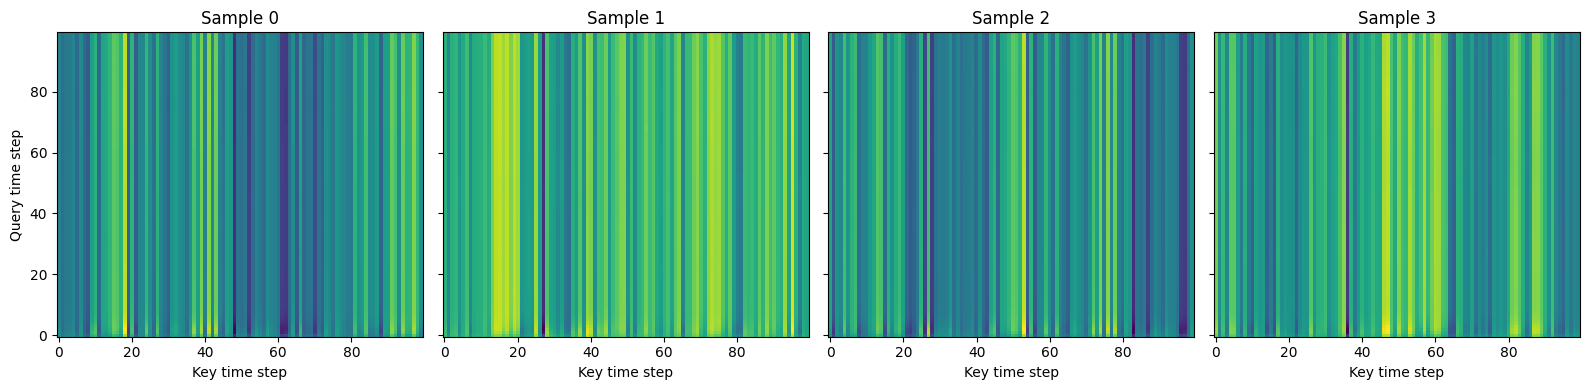

TypeError: Invalid shape (1, 100, 100) for image data

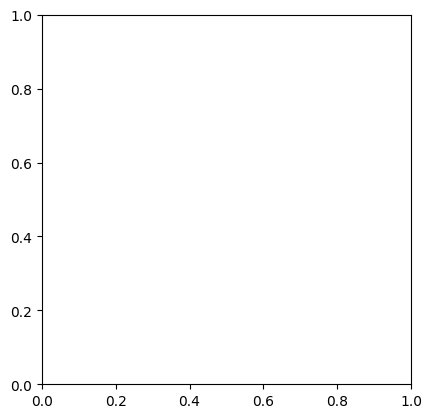

In [10]:
import torch
cross_attn_lstm_v1.eval()

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        x_batch, y_batch = batch
        #print(y_batch)
        test_prediction = cross_attn_lstm_v1(x_batch)
        attn_weights = cross_attn_lstm_v1.get_attn_weights()
        all_attn = attn_weights
        if i > 5:
            break
        
print(all_attn.shape)
attn = all_attn.detach().cpu().numpy()  
#attn = all_attn[0].detach().cpu().numpy() 
 
import random
#random.seed(42)
indices = random.sample(range(21), 4)
print("Randomly selected samples:", indices)

attn4 = attn[indices]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16,4), sharex=True, sharey=True)

im_mean = attn4.mean(0, keepdims=True)

for i, ax in enumerate(axes):
    im = ax.imshow(
        attn4[i],
        origin="lower",
        cmap="viridis",
        aspect="auto", 
       
    )
    ax.set_title(f"Sample {i}")
    ax.set_xlabel("Key time step")
    if i == 0:
        ax.set_ylabel("Query time step")



plt.tight_layout()
plt.show()

plt.imshow(im_mean)
plt.show()